# BPS VAE + Classifier

In [2]:
import os, math, json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchview import draw_graph
from IPython.display import Image
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D
import imageio.v2 as imageio
from PIL import Image
from sklearn.neighbors import NearestNeighbors
import itertools
import click

BPS_ROOT       = 'bps_dataset_256'
OUT_DIR        = 'checkpoints_modelnet10_256'
EPOCHS         = 100
BATCH_SIZE     = 64
NUM_WORKERS    = 0
LATENT_DIM     = 64
LR             = 1e-4
WEIGHT_DECAY   = 1e-5
MAX_BETA       = 1
WARMUP_EPOCHS  = 25
BETA_SCHEDULE  = 'cyclic'
RECON_LOSS     = 'mse'      # 'mse' | 'l1'
CHAMFER_WEIGHT = 0.5
GRAD_CLIP      = 0.5
CLS_WEIGHT     = 1.0        # CrossEntropy
PATIENCE       = 15         # Early stopping patience
NUM_CYCLES     = 4          # Number of beta cycles

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

os.makedirs(OUT_DIR, exist_ok=True)
print('Device:', device)

Device: cuda


In [3]:
# Carga arrays
basis     = np.load(os.path.join(BPS_ROOT, 'basis_points.npy')).astype(np.float32)
f_mean    = np.load(os.path.join(BPS_ROOT, 'feature_mean.npy')).astype(np.float32).reshape(1,-1)
f_std     = np.load(os.path.join(BPS_ROOT, 'feature_std.npy')).astype(np.float32).reshape(1,-1)
classes   = list(np.load(os.path.join(BPS_ROOT, 'classes.npy')))

te_bps    = np.load(os.path.join(BPS_ROOT, 'test_bps_std.npy')).astype(np.float32)
te_labels = np.load(os.path.join(BPS_ROOT, 'test_labels.npy')).astype(np.int64)
te_pts    = np.load(os.path.join(BPS_ROOT, 'test_points_norm.npy')).astype(np.float32)
te_c      = np.load(os.path.join(BPS_ROOT, 'test_centroids.npy')).astype(np.float32)
te_s      = np.load(os.path.join(BPS_ROOT, 'test_scales.npy')).astype(np.float32)

tr_bps    = np.load(os.path.join(BPS_ROOT, 'train_bps_std.npy')).astype(np.float32)
tr_labels = np.load(os.path.join(BPS_ROOT, 'train_labels.npy')).astype(np.int64)
tr_pts    = np.load(os.path.join(BPS_ROOT, 'train_points_norm.npy')).astype(np.float32)
tr_c      = np.load(os.path.join(BPS_ROOT, 'train_centroids.npy')).astype(np.float32)
tr_s      = np.load(os.path.join(BPS_ROOT, 'train_scales.npy')).astype(np.float32)

print('Classes:', classes)
print('Test:', te_bps.shape, '| Train:', tr_bps.shape)

def unstd(x, m, s): return x * s + m

def bps2pts(basis, feat):
    return (basis + feat.reshape(basis.shape[0], 3)).astype(np.float32)

def denorm(pts, centroid, scale):
    return pts * scale + centroid

def chamfer(a, b):
    d_ab = NearestNeighbors(n_neighbors=1).fit(b).kneighbors(a)[0][:,0]
    d_ba = NearestNeighbors(n_neighbors=1).fit(a).kneighbors(b)[0][:,0]
    return float(d_ab.mean() + d_ba.mean())

def encode_idx(bps_std, idx):
    x = torch.from_numpy(bps_std[idx].reshape(1,-1)).to(device)
    with torch.no_grad():
        mu, _ = model.encode(x)
    return mu

def decode_mu(mu):
    with torch.no_grad():
        out = model.decode(mu).cpu().numpy()
    return unstd(out, f_mean, f_std)  # (B, n_bps*3)

def plot_pc(ax, pts, color, title='', elev=20, azim=35, s=2, alpha=0.85):
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=s, c=color, alpha=alpha)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title, fontsize=10); ax.set_axis_off()
    mn, mx = pts.min(0), pts.max(0)
    c = (mn+mx)/2; r = max(np.max(mx-mn)/2, 1e-6)
    ax.set_xlim(c[0]-r,c[0]+r); ax.set_ylim(c[1]-r,c[1]+r); ax.set_zlim(c[2]-r,c[2]+r)

# índices por clase (en test set)
class_indices = {cls: np.where(te_labels == i)[0] for i, cls in enumerate(classes)}
print('Samples per class:', {k: len(v) for k,v in class_indices.items()})

Classes: [np.str_('desk'), np.str_('door'), np.str_('dresser'), np.str_('flower_pot'), np.str_('glass_box'), np.str_('keyboard'), np.str_('lamp'), np.str_('laptop'), np.str_('mantel'), np.str_('monitor')]
Test: (572, 256, 3) | Train: (1996, 256, 3)
Samples per class: {np.str_('desk'): 86, np.str_('door'): 20, np.str_('dresser'): 86, np.str_('flower_pot'): 20, np.str_('glass_box'): 100, np.str_('keyboard'): 20, np.str_('lamp'): 20, np.str_('laptop'): 20, np.str_('mantel'): 100, np.str_('monitor'): 100}


## 1. Dataset

In [4]:
class BPSDeltasDataset(Dataset):
    def __init__(self, x_path, y_path):
        x = np.load(x_path).astype(np.float32)
        y = np.load(y_path).astype(np.int64)
        assert x.ndim == 3 and x.shape[2] == 3, f'Expected (N,n_bps,3), got {x.shape}'
        self.x = x.reshape(x.shape[0], -1)
        self.y = y
        print(f'Loaded {x_path}: {x.shape} -> flat {self.x.shape}')
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return torch.from_numpy(self.x[i]), torch.tensor(self.y[i], dtype=torch.long)

train_ds = BPSDeltasDataset(
    os.path.join(BPS_ROOT, 'train_bps_std.npy'),
    os.path.join(BPS_ROOT, 'train_labels.npy'))
test_ds = BPSDeltasDataset(
    os.path.join(BPS_ROOT, 'test_bps_std.npy'),
    os.path.join(BPS_ROOT, 'test_labels.npy'))

classes      = list(np.load(os.path.join(BPS_ROOT, 'classes.npy')))
basis_points = np.load(os.path.join(BPS_ROOT, 'basis_points.npy')).astype(np.float32)
n_classes    = len(classes)
input_dim    = train_ds.x.shape[1]

kw = dict(num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'), persistent_workers=(NUM_WORKERS>0))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,  **kw)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **kw)

print(f'Classes ({n_classes}):', classes)
print(f'input_dim={input_dim}  basis={basis_points.shape}')

Loaded bps_dataset_256/train_bps_std.npy: (1996, 256, 3) -> flat (1996, 768)
Loaded bps_dataset_256/test_bps_std.npy: (572, 256, 3) -> flat (572, 768)
Classes (10): [np.str_('desk'), np.str_('door'), np.str_('dresser'), np.str_('flower_pot'), np.str_('glass_box'), np.str_('keyboard'), np.str_('lamp'), np.str_('laptop'), np.str_('mantel'), np.str_('monitor')]
input_dim=768  basis=(256, 3)


## 2. Modelo - BPSVAEClassifier

In [5]:
class BPSVAEClassifier(nn.Module):
    """
    VAE de clasificación compartiendo el encoder.
    La clasificación se hace sobre el espacio latente.
    """
    def __init__(self, input_dim: int, latent_dim=64, n_classes=3):
        super().__init__()
        self.latent_dim = latent_dim
        self.n_classes  = n_classes

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim),
        )

        # Classifier Head sobre el espacio latente
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), torch.clamp(self.fc_logvar(h), -10., 10.)

    def decode(self, z): return self.decoder(z)

    def classify(self, x):
        mu, _ = self.encode(x)
        return self.classifier(mu)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return self.decode(z), mu, logvar, self.classifier(mu)


model   = BPSVAEClassifier(input_dim=input_dim, latent_dim=LATENT_DIM, n_classes=n_classes).to(device)
n_par   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Params: {n_par:,}')

Params: 2,948,170


### 2.1 Nuevas Variantes del Modelo BPSVAEClassifier

Aquí definimos dos nuevas arquitecturas del `BPSVAEClassifier`:

*   **`BPSVAEClassifier_V2_Deeper`**: Una versión más profunda, añadiendo una capa intermedia adicional tanto en el encoder como en el decoder, y una capa más en el clasificador.
*   **`BPSVAEClassifier_V3_Wider`**: Una versión más ancha, aumentando el número de neuronas en las capas existentes del encoder y decoder, y en el clasificador.

In [6]:
class BPSVAEClassifier_V2_Deeper(nn.Module):
    def __init__(self, input_dim: int, latent_dim=64, n_classes=3):
        super().__init__()
        self.latent_dim = latent_dim
        self.n_classes  = n_classes

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(),
            nn.Linear(1024, 768), # Capa adicional
            nn.LayerNorm(768),
            nn.ReLU(),
            nn.Linear(768, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Linear(512, 768), # Capa adicional
            nn.LayerNorm(768),
            nn.ReLU(),
            nn.Linear(768, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim),
        )

        # Classifier sobre el espacio latente (más profundo)
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), torch.clamp(self.fc_logvar(h), -10., 10.)

    def decode(self, z): return self.decoder(z)

    def classify(self, x):
        mu, _ = self.encode(x)
        return self.classifier(mu)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return self.decode(z), mu, logvar, self.classifier(mu)


class BPSVAEClassifier_V3_Wider(nn.Module):
    def __init__(self, input_dim: int, latent_dim=64, n_classes=3):
        super().__init__()
        self.latent_dim = latent_dim
        self.n_classes  = n_classes

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1536), # Más ancho
            nn.LayerNorm(1536),
            nn.ReLU(),
            nn.Linear(1536, 1024), # Más ancho
            nn.LayerNorm(1024),
            nn.ReLU(),
            nn.Linear(1024, 512), # Más ancho
            nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(512, latent_dim) # Ajuste de tamaño
        self.fc_logvar = nn.Linear(512, latent_dim) # Ajuste de tamaño

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 512), # Ajuste de tamaño
            nn.ReLU(),
            nn.Linear(512, 1024), # Más ancho
            nn.LayerNorm(1024),
            nn.ReLU(),
            nn.Linear(1024, 1536), # Más ancho
            nn.LayerNorm(1536),
            nn.ReLU(),
            nn.Linear(1536, input_dim),
        )

        # Classifier Head sobre el espacio latente (más ancho)
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, n_classes),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), torch.clamp(self.fc_logvar(h), -10., 10.)

    def decode(self, z): return self.decoder(z)

    def classify(self, x):
        mu, _ = self.encode(x)
        return self.classifier(mu)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return self.decode(z), mu, logvar, self.classifier(mu)

In [7]:
model = BPSVAEClassifier(
    input_dim=input_dim, # Use global input_dim
    latent_dim=LATENT_DIM,
    n_classes=n_classes
).to(device)

# Input de ejemplo
x_dummy = torch.randn(1, input_dim).to(device) # Use global input_dim


graph = draw_graph(
    model,
    input_data=x_dummy,
    graph_name="BPSVAEClassifier",
    depth=3,               # suficiente para ver encoder/decoder/classifier
    expand_nested=True,    # muestra los Sequential internos
    show_shapes=True,
    save_graph=True,
    directory=OUT_DIR,
    filename="bps_vae"
)

In [8]:
model = BPSVAEClassifier_V2_Deeper(
    input_dim=input_dim, # Use global input_dim
    latent_dim=LATENT_DIM,
    n_classes=n_classes
).to(device)

# Input de ejemplo
x_dummy = torch.randn(1, input_dim).to(device) # Use global input_dim

graph = draw_graph(
    model,
    input_data=x_dummy,
    graph_name="BPSVAEClassifier_V2_Deeper",
    depth=3,               # suficiente para ver encoder/decoder/classifier
    expand_nested=True,    # muestra los Sequential internos
    show_shapes=True,
    save_graph=True,
    directory=OUT_DIR,
    filename="bps_vae_v2_deeper"
)

In [9]:
model = BPSVAEClassifier_V3_Wider(
    input_dim=input_dim, # Use global input_dim
    latent_dim=LATENT_DIM,
    n_classes=n_classes
).to(device)

# Input de ejemplo
x_dummy = torch.randn(1, input_dim).to(device) # Use global input_dim


graph = draw_graph(
    model,
    input_data=x_dummy,
    graph_name="BPSVAEClassifier_V3_Wider",
    depth=3,               # suficiente para ver encoder/decoder/classifier
    expand_nested=True,    # muestra los Sequential internos
    show_shapes=True,
    save_graph=True,
    directory=OUT_DIR,
    filename="bps_vae_v3_wider"
)

## 3. Loss - recon + KL + chamfer + CE

In [10]:
def chamfer_distance_batch(a, b):
    diff  = a.unsqueeze(2) - b.unsqueeze(1)
    dist2 = (diff**2).sum(-1)
    return (dist2.min(2).values.mean() + dist2.min(1).values.mean()) * 0.5


class BPSVAECLSLoss(nn.Module):
    def __init__(self, basis_points, n_bps, recon_loss_type='mse',
                 chamfer_weight=0.5, free_bits=0.5, cls_weight=1.0):
        super().__init__()
        self.recon_fn       = nn.MSELoss() if recon_loss_type == 'mse' else nn.L1Loss()
        self.ce_fn          = nn.CrossEntropyLoss()
        self.chamfer_weight = chamfer_weight
        self.cls_weight     = cls_weight
        self.n_bps          = n_bps
        self.register_buffer('basis_points',
            torch.from_numpy(np.asarray(basis_points, dtype=np.float32)))

    def kl(self, mu, logvar):
        kl = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
        return kl.mean()

    def forward(self, recon, target, mu, logvar, logits, labels, beta):
        recon_loss = self.recon_fn(recon, target)
        kl         = self.kl(mu, logvar)
        ce         = self.ce_fn(logits, labels)
        B          = recon.shape[0]
        bp         = self.basis_points.unsqueeze(0)
        chamfer    = chamfer_distance_batch(
            bp + recon.view(B, self.n_bps, 3),
            bp + target.view(B, self.n_bps, 3))
        total = recon_loss + beta*kl + self.chamfer_weight*chamfer + self.cls_weight*ce
        return total, recon_loss, kl, chamfer, ce


criterion = BPSVAECLSLoss(
    basis_points=basis_points, n_bps=basis_points.shape[0],
    recon_loss_type=RECON_LOSS, chamfer_weight=CHAMFER_WEIGHT, cls_weight=CLS_WEIGHT,
).to(device)

## 4. Loop de entrenamiento

In [11]:
def get_beta(epoch, max_beta=1, warmup_epochs=25, schedule='cosine', num_cycles=1, total_epochs=100):
    if schedule == 'cyclic':
        cycle_length = total_epochs / num_cycles
        epoch_in_cycle = epoch % cycle_length
        p = epoch_in_cycle / (cycle_length - 1) # Normalizing to 0-1 over the cycle
        return max_beta * ((1 - math.cos(math.pi * p)) / 2) # Smooth ramp-up using cosine
    elif warmup_epochs <= 0:
        return max_beta
    else:
        p = min(epoch / warmup_epochs, 1.0)
        return max_beta * ((1 - math.cos(math.pi * p)) / 2 if schedule == 'cosine' else p)


def run_epoch(model, loader, criterion, device, beta, optimizer=None, grad_clip=1.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    totals = {'loss':0., 'recon':0., 'kl':0., 'chamfer':0., 'ce':0., 'correct':0, 'n':0}
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            recon, mu, logvar, logits = model(x)
            loss, rl, kl, ch, ce     = criterion(recon, x, mu, logvar, logits, y, beta)
            if not torch.isfinite(loss): print('Non-finite loss, skip.'); continue
            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
            totals['loss']    += loss.item()
            totals['recon']   += rl.item()
            totals['kl']      += kl.item()
            totals['chamfer'] += ch.item()
            totals['ce']      += ce.item()
            totals['correct'] += (logits.argmax(1) == y).sum().item()
            totals['n']       += len(y)
    nb  = max(len(loader), 1)
    acc = totals['correct'] / max(totals['n'], 1) * 100
    return {k: totals[k]/nb for k in ('loss','recon','kl','chamfer','ce')} | {'acc': acc}


optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

## 5. Entrenamiento
https://docs.pytorch.org/docs/stable/nn.init.html

In [12]:
def create_model(model_architecture='BPSVAEClassifier', input_dim=None, latent_dim=None, n_classes=None, initialization_method='default'):
    """Factory function to create a new model instance with new weights and specified initialization.
    Available architectures: 'BPSVAEClassifier', 'BPSVAEClassifier_V2_Deeper', 'BPSVAEClassifier_V3_Wider'
    Available initialization methods: 'default', 'xavier_uniform', 'xavier_normal'
    """
    # Use global values if not provided explicitly
    input_dim_actual = input_dim if input_dim is not None else globals().get('input_dim')
    latent_dim_actual = latent_dim if latent_dim is not None else globals().get('LATENT_DIM')
    n_classes_actual = n_classes if n_classes is not None else globals().get('n_classes')

    if model_architecture == 'BPSVAEClassifier':
        model = BPSVAEClassifier(input_dim=input_dim_actual, latent_dim=latent_dim_actual, n_classes=n_classes_actual)
    elif model_architecture == 'BPSVAEClassifier_V2_Deeper':
        model = BPSVAEClassifier_V2_Deeper(input_dim=input_dim_actual, latent_dim=latent_dim_actual, n_classes=n_classes_actual)
    elif model_architecture == 'BPSVAEClassifier_V3_Wider':
        model = BPSVAEClassifier_V3_Wider(input_dim=input_dim_actual, latent_dim=latent_dim_actual, n_classes=n_classes_actual)
    else:
        raise ValueError(f"Unknown model architecture: {model_architecture}")

    if initialization_method != 'default':
        for m in model.modules():
            if isinstance(m, nn.Linear):
                if initialization_method == 'xavier_uniform':
                    nn.init.xavier_uniform_(m.weight)
                elif initialization_method == 'xavier_normal':
                    nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    return model

In [13]:
def run_training_experiment(run_idx, model_factory, train_ds, test_ds, criterion, device,
                            epochs, max_beta, warmup_epochs, beta_schedule, num_cycles,
                            total_epochs, lr, weight_decay, grad_clip, patience, out_dir,
                            batch_size, recon_loss_type, chamfer_weight, cls_weight,
                            initialization_method='default'):
    print(f"\n--- Starting Experiment Run {run_idx+1} (Init: {initialization_method}, BS: {batch_size}, LR: {lr}, WD: {weight_decay}, RL: {recon_loss_type}, CW: {chamfer_weight}, GC: {grad_clip}, CLSW: {cls_weight}) ---")

    # Re-initialize model for each run with specified method
    # Pass explicit dimensions to model_factory
    model = model_factory(initialization_method=initialization_method, input_dim=input_dim, latent_dim=LATENT_DIM, n_classes=n_classes).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    # Re-create data loaders for current batch_size
    kw = dict(num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'), persistent_workers=(NUM_WORKERS>0))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=True,  **kw)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False, **kw)

    # Re-create criterion for current recon_loss_type, chamfer_weight, cls_weight
    current_criterion = BPSVAECLSLoss(
        basis_points=basis_points, n_bps=basis_points.shape[0],
        recon_loss_type=recon_loss_type, chamfer_weight=chamfer_weight, cls_weight=cls_weight,
    ).to(device)

    history = []
    best_val_acc = -float('inf') # Track best validation accuracy
    patience_counter = 0
    best_model_state_dict = None
    best_epoch = 0

    for epoch in range(1, epochs + 1):
        beta = get_beta(epoch-1, max_beta, warmup_epochs, beta_schedule, num_cycles=num_cycles, total_epochs=total_epochs)
        tr   = run_epoch(model, train_loader, current_criterion, device, beta, optimizer, grad_clip)
        va   = run_epoch(model, test_loader,  current_criterion, device, beta)
        scheduler.step()

        history.append({'epoch': epoch, 'beta': beta,
                        **{f'tr_{k}': v for k,v in tr.items()},
                        **{f'va_{k}': v for k,v in va.items()}})

        msg = (
            f"[{epoch:03d}/{epochs}] "
            f"{click.style(f'β={beta:.5f}', fg='yellow')} | "
            f"{click.style('train', fg='blue', bold=True)} "
            f"loss={tr['loss']:.4f} recon={tr['recon']:.4f} kl={tr['kl']:.4f} "
            f"ch={tr['chamfer']:.4f} ce={tr['ce']:.4f} acc={tr['acc']:.1f}% | "
            f"{click.style('val', fg='magenta', bold=True)} "
            f"loss={va['loss']:.4f} recon={va['recon']:.4f} kl={va['kl']:.4f} "
            f"ch={va['chamfer']:.4f} ce={va['ce']:.4f} acc={va['acc']:.1f}%"
        )
        click.echo(msg)

        # Track best validation accuracy
        if math.isfinite(va['acc']) and va['acc'] > best_val_acc:
            best_val_acc = va['acc']
            patience_counter = 0
            best_model_state_dict = model.state_dict() # Store the best model weights
            best_epoch = epoch
            print(f"  ✓ best val_acc={best_val_acc:.1f}%")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered after {patience_counter} epochs without improvement for run {run_idx+1}.")
            break

    print(f'--- Run {run_idx+1} Done. Best val accuracy: {best_val_acc:.1f}% at epoch {best_epoch} ---')
    return history, best_val_acc, best_model_state_dict, best_epoch

In [14]:
param_grid = {
    'lr': [1e-4, 5e-5],
    'batch_size': [32, 64],
    'weight_decay': [1e-5, 1e-6],
    'recon_loss_type': ['mse'],
    'chamfer_weight': [0.5, 1.0],
    'grad_clip': [0.5],
    'cls_weight': [1.0, 2.0],
    'initialization_method': ['default', 'xavier_uniform', 'xavier_normal'],
    'model_architecture': ['BPSVAEClassifier', 'BPSVAEClassifier_V2_Deeper', 'BPSVAEClassifier_V3_Wider']
}

# Generate all combinations of hyperparameters
keys = param_grid.keys()
combinations = list(itertools.product(*param_grid.values()))

all_grid_search_histories = []
all_grid_search_best_accs = []
overall_best_grid_search_acc = -float('inf')
overall_best_grid_search_model_state_dict = None
overall_best_grid_search_params = None

print(f"\n--- Starting Grid Search with {len(combinations)} combinations ---")

for i, combo in enumerate(combinations):
    current_params = dict(zip(keys, combo))

    print(f"\nRunning Grid Search Combination {i+1}/{len(combinations)}:")
    print(current_params)

    # Pass input_dim, latent_dim, n_classes explicitly to model_factory
    history, best_val_acc_run, best_state_dict_run, best_epoch_run = run_training_experiment(
        run_idx=i, # Use 'i' as the run_idx for grid search
        model_factory=lambda initialization_method, input_dim, latent_dim, n_classes: create_model(
            model_architecture=current_params['model_architecture'],
            input_dim=input_dim, latent_dim=latent_dim, n_classes=n_classes,
            initialization_method=initialization_method
        ),
        train_ds=train_ds,
        test_ds=test_ds,
        criterion=criterion,
        device=device,
        epochs=EPOCHS,
        max_beta=MAX_BETA,
        warmup_epochs=WARMUP_EPOCHS,
        beta_schedule=BETA_SCHEDULE,
        num_cycles=NUM_CYCLES,
        total_epochs=EPOCHS,
        grad_clip=current_params['grad_clip'],
        patience=PATIENCE,
        out_dir=OUT_DIR,
        initialization_method=current_params['initialization_method'],

        # Grid Search Parameters
        lr=current_params['lr'],
        batch_size=current_params['batch_size'],
        weight_decay=current_params['weight_decay'],
        recon_loss_type=current_params['recon_loss_type'],
        chamfer_weight=current_params['chamfer_weight'],
        cls_weight=current_params['cls_weight']
    )

    all_grid_search_histories.append(history)
    all_grid_search_best_accs.append(best_val_acc_run)

    if best_val_acc_run > overall_best_grid_search_acc:
        overall_best_grid_search_acc = best_val_acc_run
        overall_best_grid_search_model_state_dict = best_state_dict_run
        overall_best_grid_search_params = current_params

# Save the overall best model from the grid search
if overall_best_grid_search_model_state_dict is not None:
    final_grid_search_ckpt = {
        'epoch': best_epoch_run,
        'model': overall_best_grid_search_model_state_dict,
        'args': {
            'latent_dim': LATENT_DIM,
            'input_dim': input_dim, # Store the actual input_dim used
            'n_classes': n_classes,
            **overall_best_grid_search_params
        },
        'best_val_acc': overall_best_grid_search_acc # Store best accuracy
    }
    torch.save(final_grid_search_ckpt, os.path.join(OUT_DIR, 'overall_best_grid_search.pt'))
    print(f"\nOverall best model from Grid Search saved with validation accuracy: {overall_best_grid_search_acc:.2f}%")
    print(f"Best parameters: {overall_best_grid_search_params}")

print("\n--- Summary of all Grid Search runs ---")
for i, acc in enumerate(all_grid_search_best_accs): # Iterate through accuracies
    current_params = dict(zip(keys, combinations[i]))
    print(f"Run {i+1}: Best Validation Accuracy = {acc:.2f}% (Params: {current_params})")
print(f"Overall Best Validation Accuracy across all Grid Search runs: {overall_best_grid_search_acc:.2f}%")
print(f"Overall Best Parameters: {overall_best_grid_search_params}")


--- Starting Grid Search with 288 combinations ---

Running Grid Search Combination 1/288:
{'lr': 0.0001, 'batch_size': 32, 'weight_decay': 1e-05, 'recon_loss_type': 'mse', 'chamfer_weight': 0.5, 'grad_clip': 0.5, 'cls_weight': 1.0, 'initialization_method': 'default', 'model_architecture': 'BPSVAEClassifier'}

--- Starting Experiment Run 1 (Init: default, BS: 32, LR: 0.0001, WD: 1e-05, RL: mse, CW: 0.5, GC: 0.5, CLSW: 1.0) ---
[001/100] β=0.00000 | train loss=3.0188 recon=1.0009 kl=0.2816 ch=0.3796 ce=1.8281 acc=52.7% | val loss=2.2894 recon=0.8124 kl=0.6820 ch=0.3238 ce=1.3151 acc=78.0%
  ✓ best val_acc=78.0%
[002/100] β=0.00428 | train loss=1.8461 recon=0.7050 kl=1.3472 ch=0.2969 ce=0.9869 acc=77.6% | val loss=1.3859 recon=0.6204 kl=1.9903 ch=0.2563 ce=0.6288 acc=89.0%
  ✓ best val_acc=89.0%
[003/100] β=0.01704 | train loss=1.2986 recon=0.5866 kl=2.4788 ch=0.2559 ce=0.5418 acc=88.0% | val loss=1.0887 recon=0.5485 kl=2.8951 ch=0.2338 ce=0.3740 acc=91.8%
  ✓ best val_acc=91.8%
[004/10

In [15]:
data = []
for i, combo in enumerate(combinations):
    current_params = dict(zip(keys, combo))
    row = {
        **current_params,
        'best_val_acc': all_grid_search_best_accs[i]
    }
    data.append(row)

# Create DataFrame
results_df = pd.DataFrame(data)
results_df = results_df.sort_values(by='best_val_acc', ascending=False).reset_index(drop=True)
csv_path = os.path.join(OUT_DIR, 'grid_search_results.csv')
results_df.to_csv(csv_path, index=False)


print("\nTop 10 Grid Search Results (sorted by best validation accuracy):")
display(results_df.head(10))


Top 10 Grid Search Results (sorted by best validation accuracy):


,lr,batch_size,weight_decay,recon_loss_type,chamfer_weight,grad_clip,cls_weight,initialization_method,model_architecture,best_val_acc
0,0.00005,32,0.000010,mse,0.5,0.5,1.0,xavier_uniform,BPSVAEClassifier_V3_Wider,95.804196
1,0.00010,32,0.000010,mse,0.5,0.5,1.0,xavier_normal,BPSVAEClassifier,95.804196
2,0.00010,32,0.000010,mse,0.5,0.5,1.0,xavier_normal,BPSVAEClassifier_V2_Deeper,95.804196
3,0.00005,32,0.000001,mse,1.0,0.5,1.0,xavier_normal,BPSVAEClassifier_V3_Wider,95.804196
4,0.00010,64,0.000010,mse,1.0,0.5,1.0,xavier_normal,BPSVAEClassifier_V2_Deeper,95.804196
5,0.00010,64,0.000010,mse,1.0,0.5,2.0,xavier_uniform,BPSVAEClassifier_V3_Wider,95.804196
6,0.00005,64,0.000001,mse,0.5,0.5,1.0,xavier_normal,BPSVAEClassifier_V3_Wider,95.629371
7,0.00010,64,0.000001,mse,0.5,0.5,1.0,xavier_normal,BPSVAEClassifier_V3_Wider,95.629371
8,0.00010,64,0.000001,mse,0.5,0.5,2.0,default,BPSVAEClassifier_V3_Wider,95.629371
9,0.00010,32,0.000010,mse,1.0,0.5,1.0,xavier_normal,BPSVAEClassifier_V3_Wider,95.629371


## 6. Curvas de entrenamiento

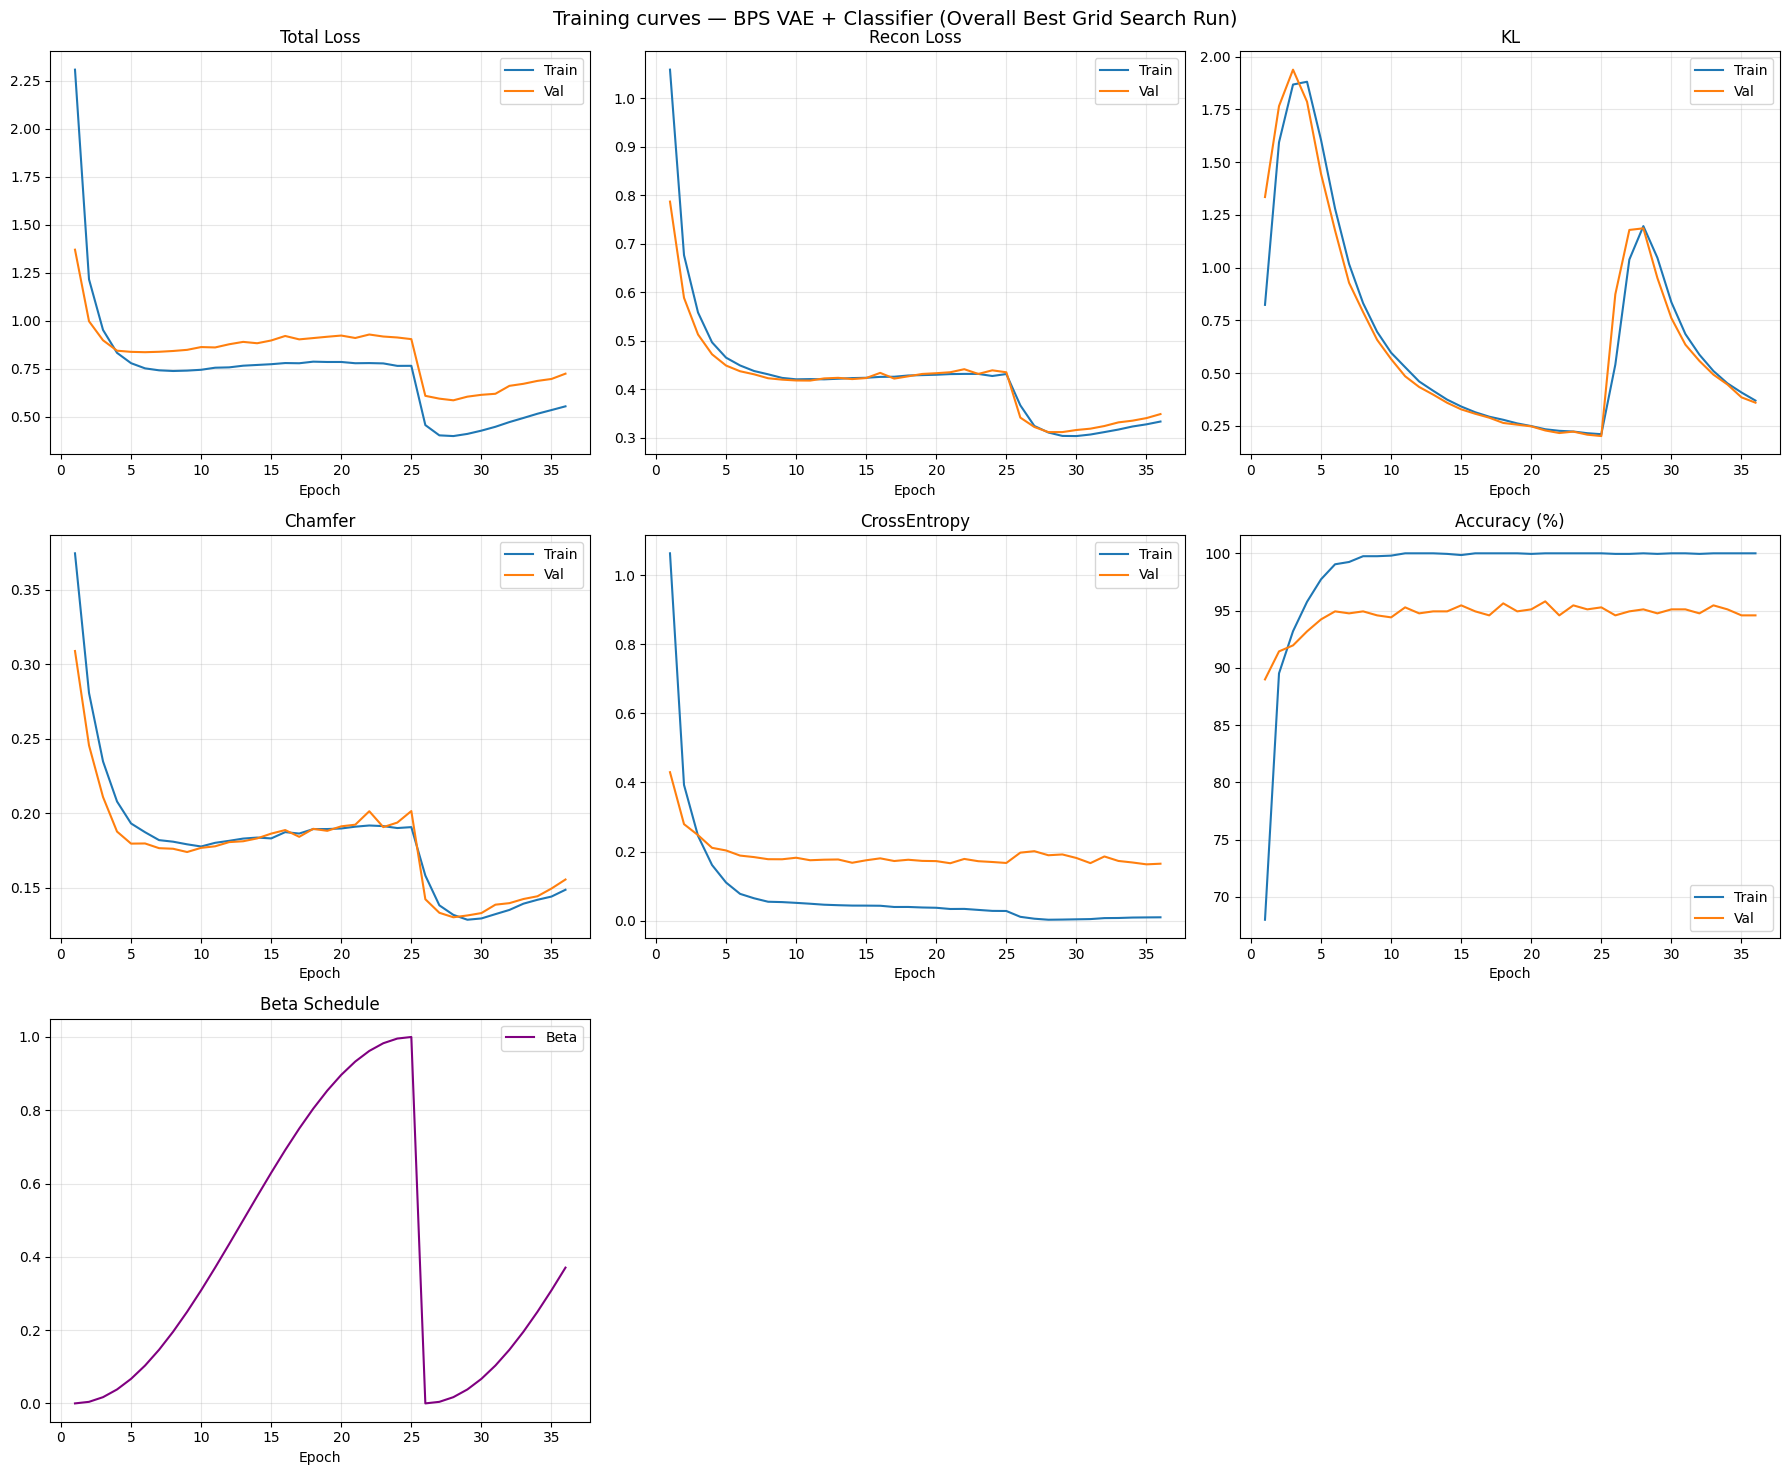

In [16]:
# Use the history from the overall best grid search run
overall_best_grid_search_run_idx = all_grid_search_best_accs.index(overall_best_grid_search_acc)
best_history = all_grid_search_histories[overall_best_grid_search_run_idx]
ep  = [h['epoch'] for h in best_history]
mets = ['loss','recon','kl','chamfer','ce','acc', 'beta']
tits = ['Total Loss','Recon Loss','KL','Chamfer','CrossEntropy','Accuracy (%)', 'Beta Schedule']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
for ax, m, t in zip(axes.flat, mets, tits):
    if m == 'beta':
        ax.plot(ep, [h[m] for h in best_history], label='Beta', color='purple')
    else:
        ax.plot(ep, [h[f'tr_{m}'] for h in best_history], label='Train', color='#1f77b4')
        ax.plot(ep, [h[f'va_{m}'] for h in best_history], label='Val',   color='#ff7f0e')
    ax.set_title(t); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

for i in range(len(mets), len(axes.flat)):
    fig.delaxes(axes.flat[i])

plt.suptitle('Training curves — BPS VAE + Classifier (Overall Best Grid Search Run)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'training_curves_grid_search.png'), dpi=150)
plt.show()

## 7. Evaluación - Accuracy, Confusion Matrix, Classification Report

Loaded overall best checkpoint — epoch 13

Train Accuracy: 100.00%
Test  Accuracy: 94.58%

              precision    recall  f1-score   support

        desk       0.95      0.93      0.94        86
        door       0.91      1.00      0.95        20
     dresser       0.98      0.95      0.96        86
  flower_pot       0.94      0.80      0.86        20
   glass_box       0.97      0.96      0.96       100
    keyboard       0.95      1.00      0.98        20
        lamp       0.73      0.80      0.76        20
      laptop       0.83      0.95      0.88        20
      mantel       0.98      0.97      0.97       100
     monitor       0.94      0.95      0.95       100

    accuracy                           0.95       572
   macro avg       0.92      0.93      0.92       572
weighted avg       0.95      0.95      0.95       572



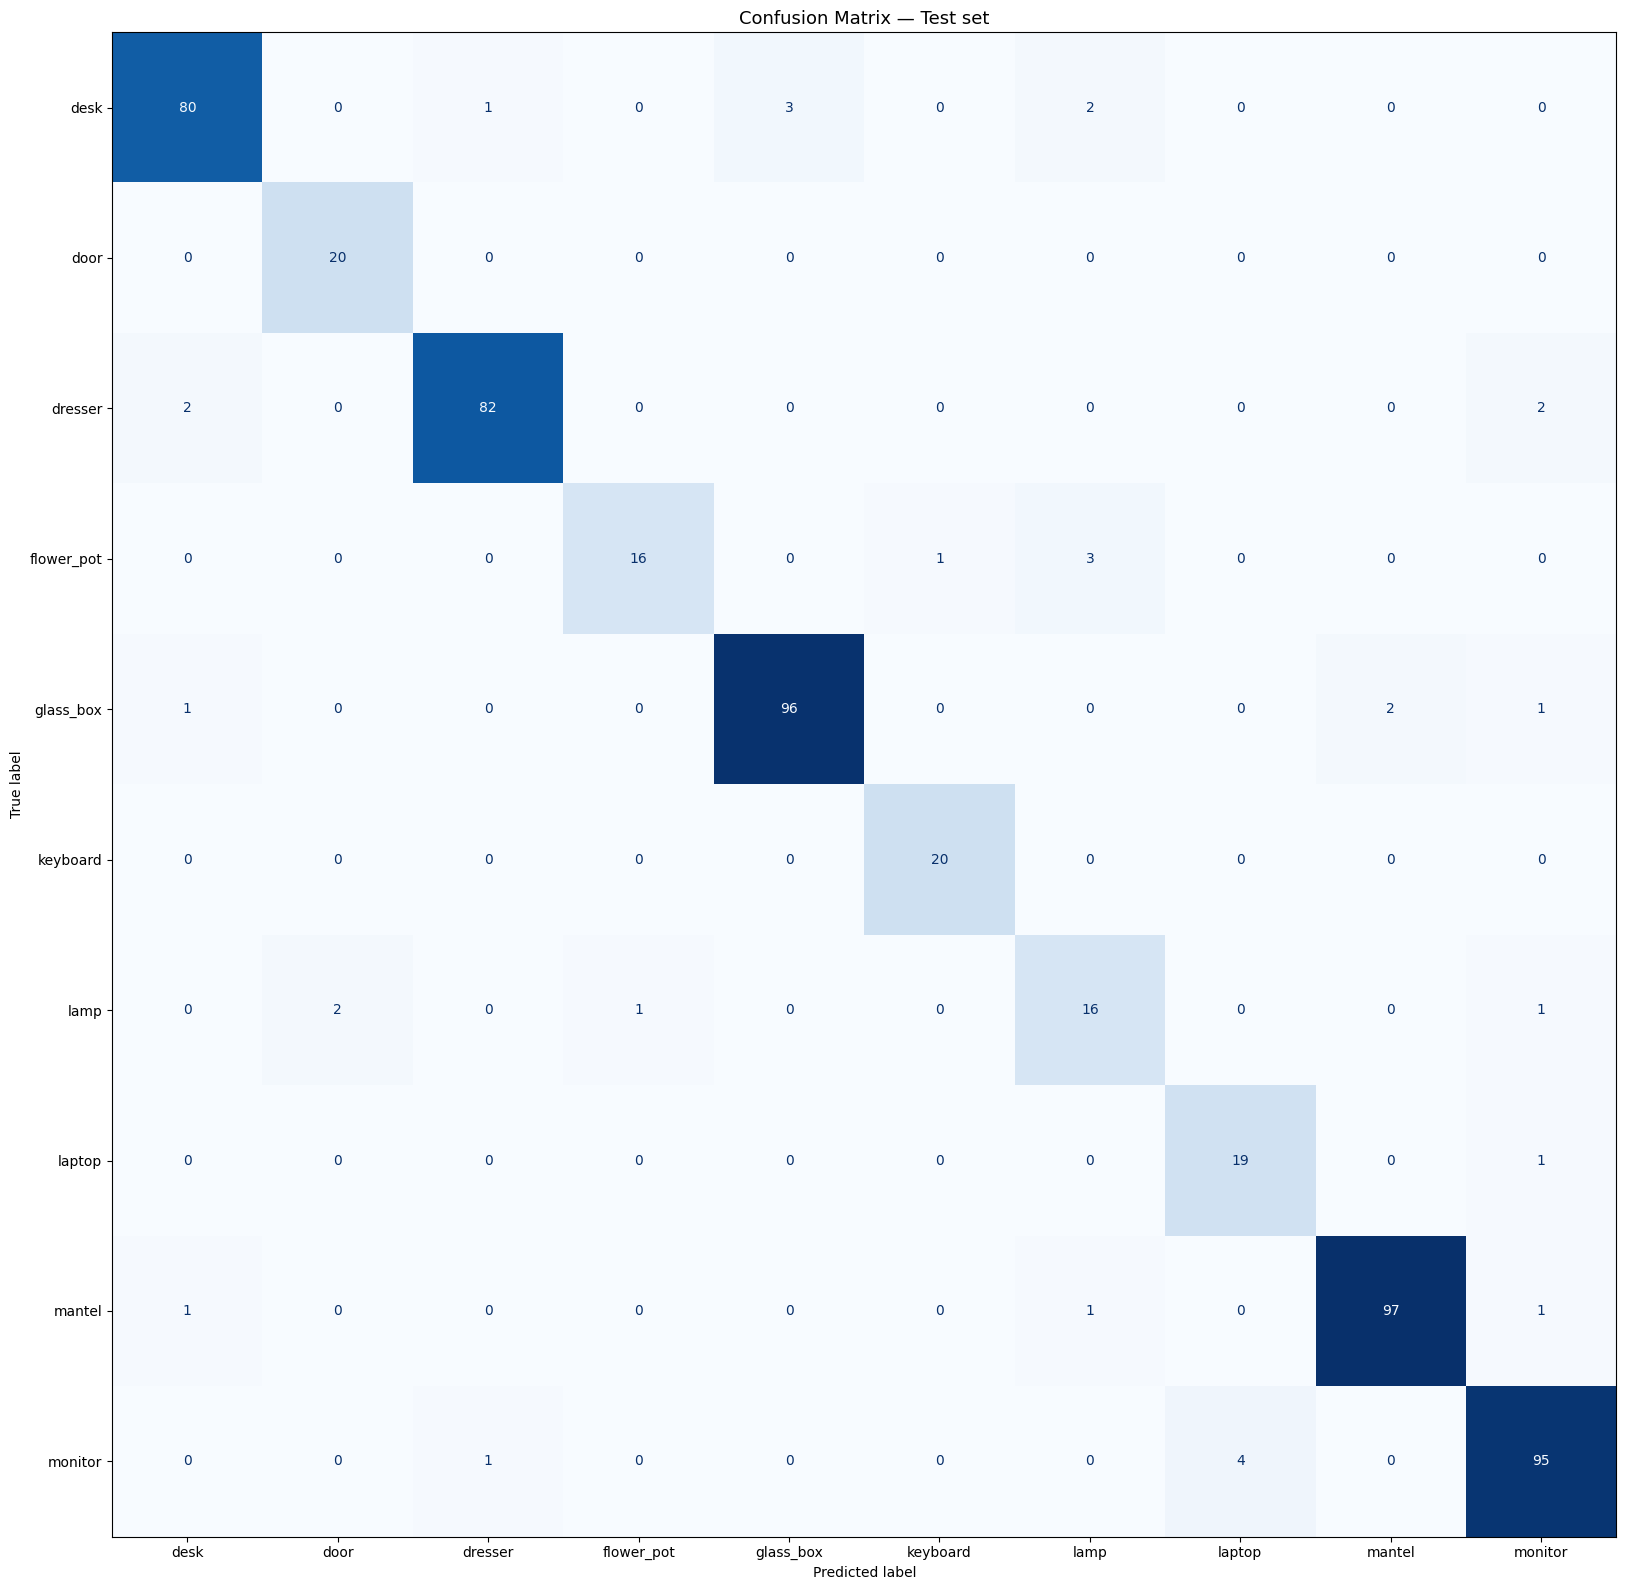

In [17]:
@torch.no_grad()
def get_preds_and_latents(model, loader, device):
    preds, labels, mus = [], [], []
    model.eval()

    for x, y in loader:
        # Mover x al device y ASEGURAR que sea float32
        x = x.to(device).float()

        # Obtener latentes
        mu, _ = model.encode(x)
        logits = model.classifier(mu)

        preds.append(logits.argmax(1).cpu().numpy())
        labels.append(y.numpy())
        mus.append(mu.cpu().numpy())

        # Liberar memoria de MPS en cada iteración
        if device.type == 'mps':
            torch.mps.empty_cache()

    return np.concatenate(preds), np.concatenate(labels), np.concatenate(mus)

# Load the overall best model checkpoint
best_ckpt = torch.load(os.path.join(OUT_DIR, 'overall_best_grid_search.pt'), map_location=device)

# Re-initialize the model with the correct architecture and dimensions from the best checkpoint
best_model_architecture = best_ckpt['args']['model_architecture']
best_input_dim = best_ckpt['args']['input_dim']
best_latent_dim = best_ckpt['args']['latent_dim']
best_n_classes = best_ckpt['args']['n_classes']

# Use the create_model function to get an instance of the correct model
# The initialization method doesn't matter here as we are loading state_dict
model = create_model(
    model_architecture=best_model_architecture,
    input_dim=best_input_dim,
    latent_dim=best_latent_dim,
    n_classes=best_n_classes
).to(device)

model.load_state_dict(best_ckpt['model'])
print(f'Loaded overall best checkpoint — epoch {best_ckpt["epoch"]}')

tr_preds, tr_lbl, tr_mus = get_preds_and_latents(model, train_loader, device)
te_preds, te_lbl, te_mus = get_preds_and_latents(model, test_loader,  device)

print(f'\nTrain Accuracy: {accuracy_score(tr_lbl, tr_preds)*100:.2f}%')
print(f'Test  Accuracy: {accuracy_score(te_lbl, te_preds)*100:.2f}%\n')
print(classification_report(te_lbl, te_preds, target_names=classes))

cm = confusion_matrix(te_lbl, te_preds)
fig, ax = plt.subplots(figsize=(max(6, n_classes*1.8), max(5, n_classes*1.6)))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test set', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

## 8. Comparativa: VAE+Cls vs kNN vs XGBoost


=== Accuracy Comparison (Test) ===
  VAE + Classifier head              : 94.58%
  kNN on latents                     : 94.93%
  XGBoost on latents                 : 93.36%


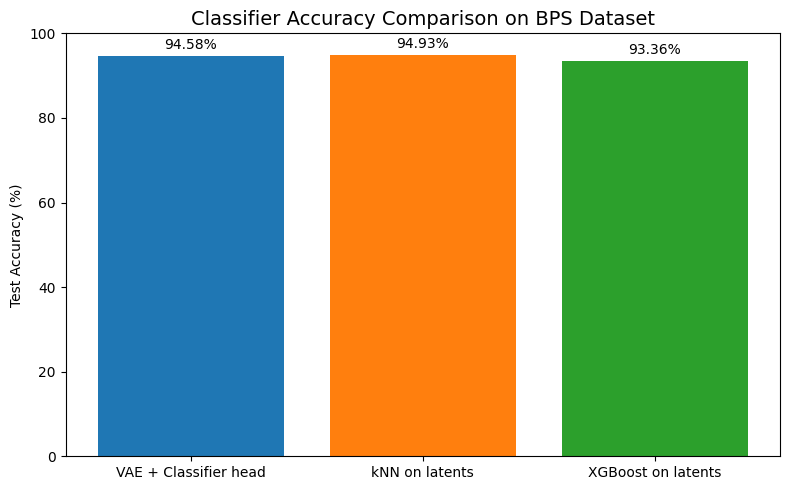

In [18]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(tr_mus, tr_lbl)
knn_acc = accuracy_score(te_lbl, knn.predict(te_mus)) * 100

xgboost = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgboost.fit(tr_mus, tr_lbl)
xgboost_acc = accuracy_score(te_lbl, xgboost.predict(te_mus)) * 100

vaecls_acc = accuracy_score(te_lbl, te_preds) * 100

results = {
    'VAE + Classifier head':      vaecls_acc,
    'kNN on latents':             knn_acc,
    'XGBoost on latents':         xgboost_acc,
}
print('\n=== Accuracy Comparison (Test) ===')
for k, v in results.items():
    print(f'  {k:35s}: {v:.2f}%')

fig = plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), results.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylim(0, 100)
plt.ylabel('Test Accuracy (%)')
plt.title('Classifier Accuracy Comparison on BPS Dataset', fontsize=14)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'accuracy_comparison.png'), dpi=150)
plt.show()

## 9. t-SNE del espacio latente

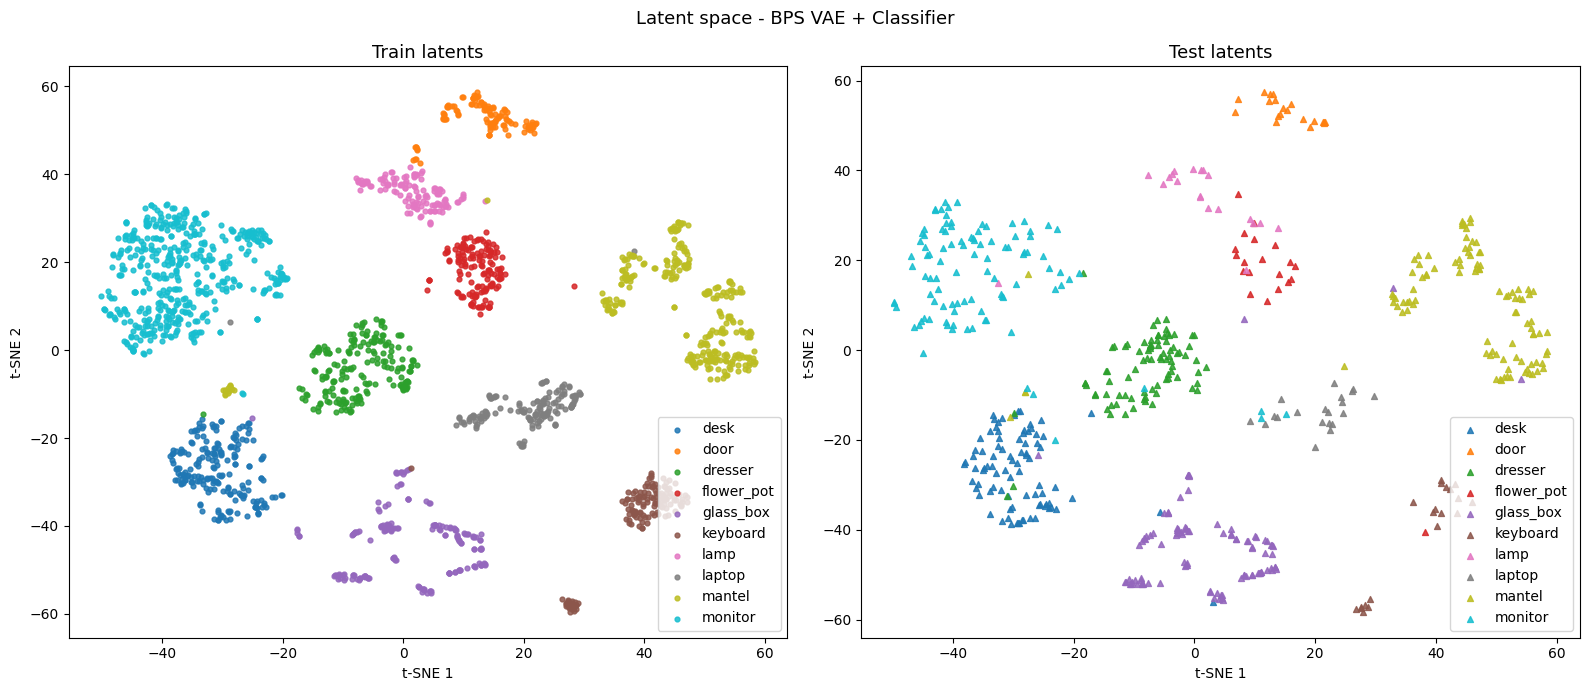

In [19]:
all_mus    = np.concatenate([tr_mus, te_mus])
all_labels = np.concatenate([tr_lbl, te_lbl])
split_tag  = np.array(['train']*len(tr_mus) + ['test']*len(te_mus))

coords = TSNE(n_components=2, init='pca',
              learning_rate='auto', random_state=42).fit_transform(all_mus)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors    = plt.cm.tab10(np.linspace(0, 1, n_classes))

for ax, sp, mk, sz, title in [
    (axes[0], 'train', 'o', 12, 'Train latents'),
    (axes[1], 'test',  '^', 18, 'Test latents'),
]:
    m_sp = split_tag == sp
    for idx, (name, color) in enumerate(zip(classes, colors)):
        mask = m_sp & (all_labels == idx)
        ax.scatter(coords[mask,0], coords[mask,1], s=sz, color=color,
                   alpha=0.85, marker=mk, label=name)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=10)

plt.suptitle('Latent space - BPS VAE + Classifier', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'tsne_latents.png'), dpi=200)
plt.show()

/tmp/ipykernel_19021/1682879978.py:47: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=s, c=color, alpha=alpha)


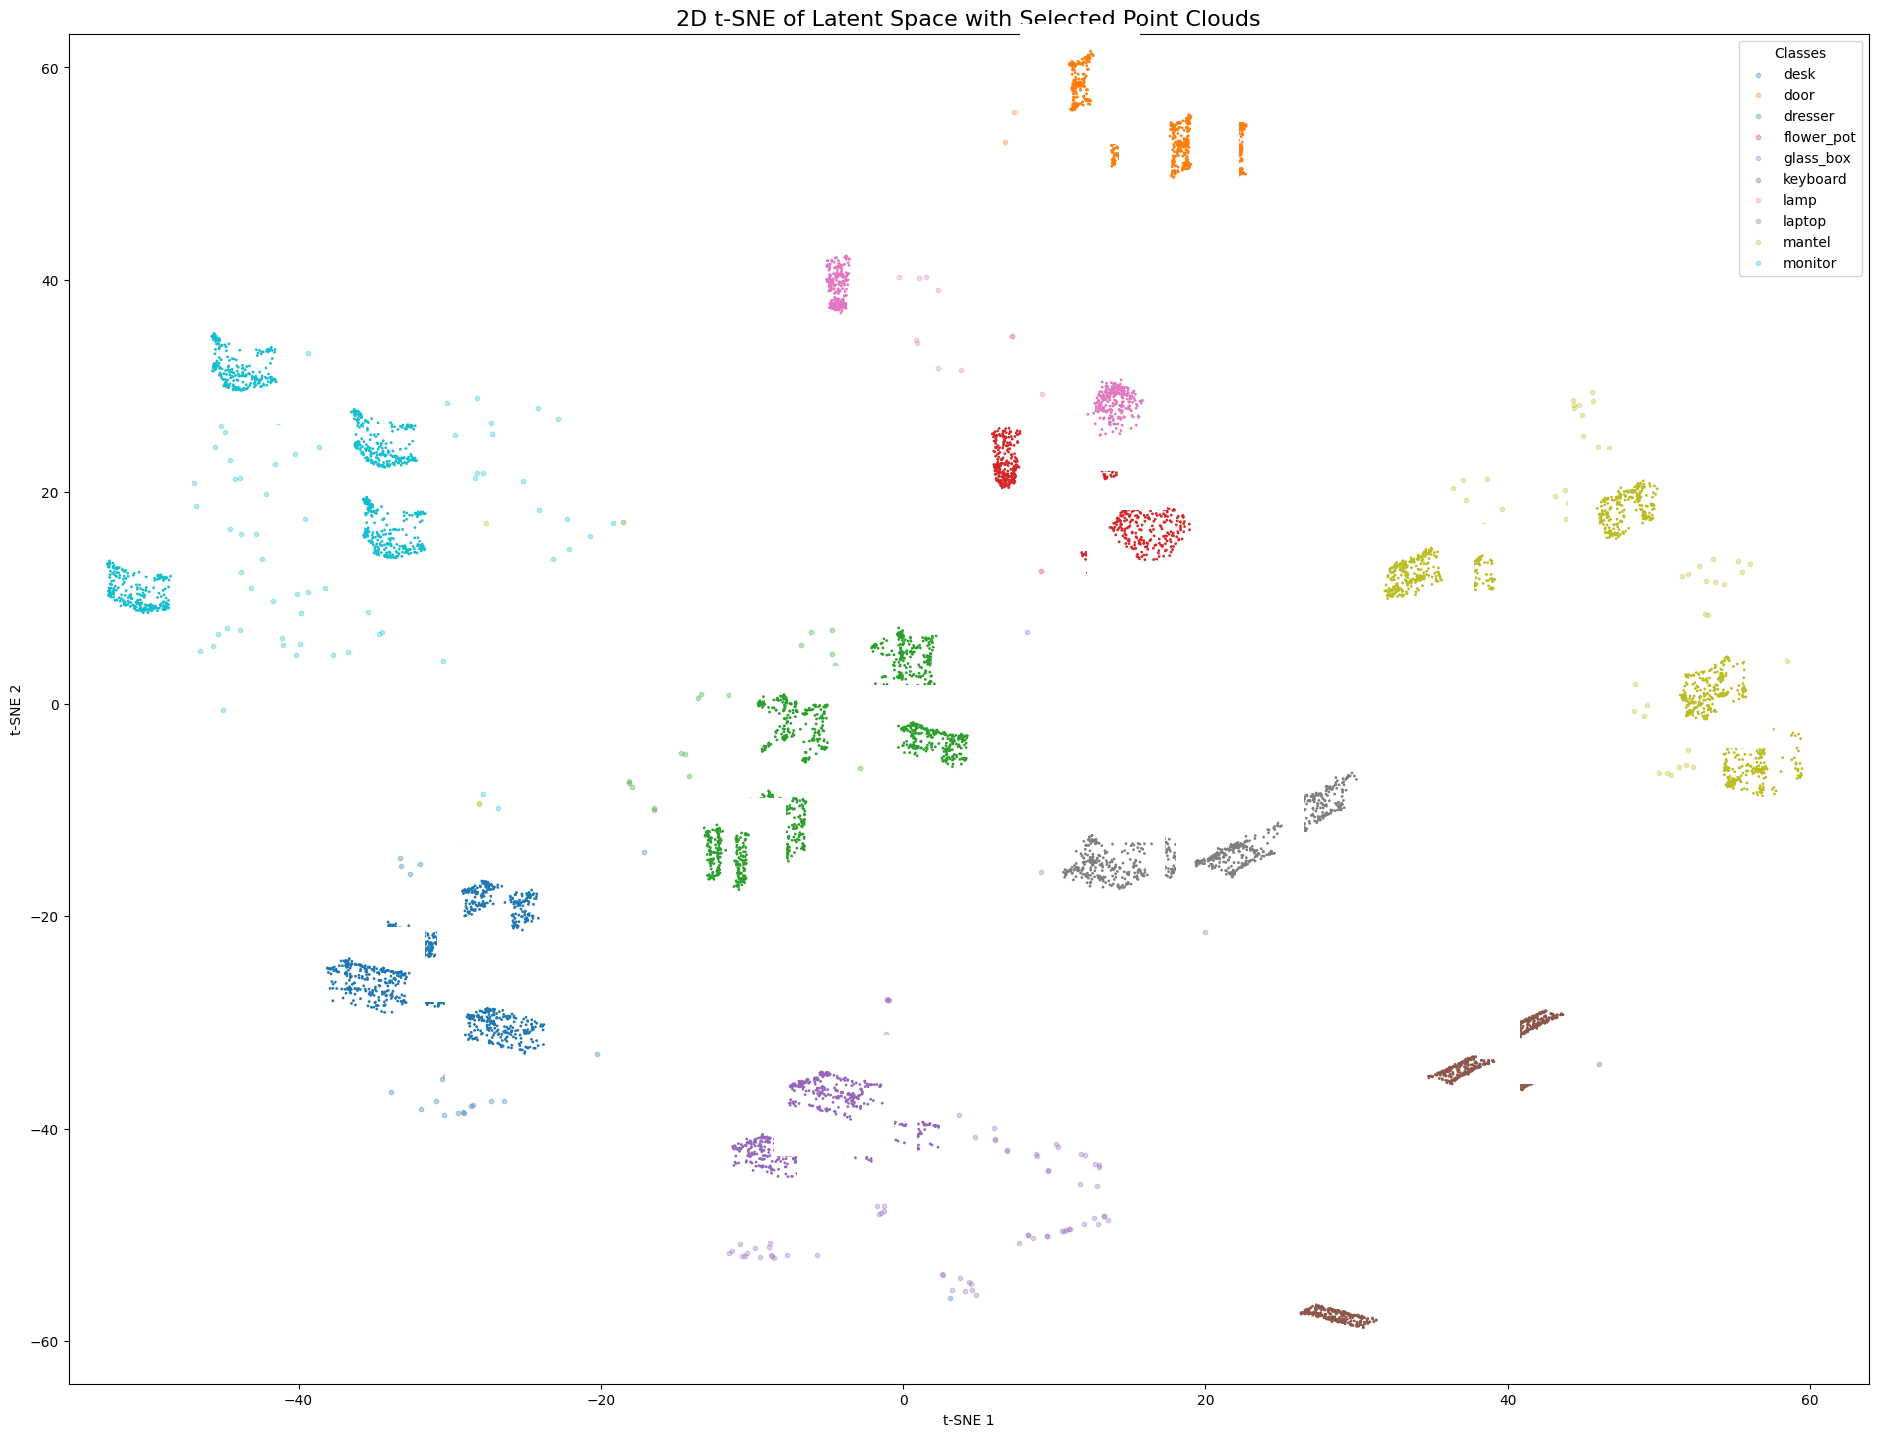

In [20]:
N_DISPLAY_PER_CLASS = 5 # Number of point clouds to display per class

selected_indices = []
for i, cls_name in enumerate(classes):
    # Get test indices for this class
    test_indices_for_class = np.where(te_labels == i)[0]
    # Pick a few from the test set
    if len(test_indices_for_class) > 0:
        # Randomly select N_DISPLAY_PER_CLASS, or all if fewer are available
        num_to_select = min(N_DISPLAY_PER_CLASS, len(test_indices_for_class))
        np.random.seed(42) # For reproducibility
        selected_from_class = np.random.choice(test_indices_for_class, num_to_select, replace=False)
        selected_indices.extend(selected_from_class)

# Get the t-SNE coordinates for the all test set
coords_test = coords[len(tr_mus):] # `coords` is for all_mus (train + test)

fig = plt.figure(figsize=(20, 15))

# Plot all t-SNE points in the background for context
ax_bg = fig.add_subplot(111)
colors_all = plt.cm.tab10(np.linspace(0, 1, n_classes))
for idx, (name, color) in enumerate(zip(classes, colors_all)):
    mask = (te_labels == idx)
    ax_bg.scatter(coords_test[mask, 0], coords_test[mask, 1], s=10, color=color, alpha=0.3, label=name)
ax_bg.set_title('2D t-SNE of Latent Space with Selected Point Clouds', fontsize=16)
ax_bg.set_xlabel('t-SNE 1'); ax_bg.set_ylabel('t-SNE 2')
ax_bg.legend(title='Classes')

# Normalize t-SNE coordinates to figure coordinates (0 to 1) for placing subplots
min_x, max_x = coords_test[:, 0].min(), coords_test[:, 0].max()
min_y, max_y = coords_test[:, 1].min(), coords_test[:, 1].max()

# Add some padding to the min/max range to ensure small 3D plots don't get cut off at edges
pad_x = (max_x - min_x) * 0.1
pad_y = (max_y - min_y) * 0.1
min_x -= pad_x; max_x += pad_x
min_y -= pad_y; max_y += pad_y

def normalize_coord(val, min_val, max_val):
    return (val - min_val) / (max_val - min_val)

subplot_size = 0.08 # Relative size of each 3D subplot (width and height)

# Loop through selected indices and add 3D point cloud subplots
for g_idx in selected_indices:
    original_test_idx = g_idx # This is the index within the test set (te_bps, te_labels)

    # Get t-SNE coordinates for this object
    tsne_x, tsne_y = coords_test[original_test_idx, 0], coords_test[original_test_idx, 1]

    # Normalize these coordinates to the figure's [0,1] range
    fig_x = normalize_coord(tsne_x, min_x, max_x)
    fig_y = normalize_coord(tsne_y, min_y, max_y)

    # Calculate position for the 3D subplot (bottom-left corner)
    # Adjust fig_y so that the object is roughly centered at its t-SNE y-coordinate
    ax_pos = [fig_x - subplot_size/2, fig_y - subplot_size/2, subplot_size, subplot_size]

    # Reconstruct the point cloud for the selected test index
    mu_latent = encode_idx(te_bps, original_test_idx) # Use te_bps for test data
    r_bps_denorm = decode_mu(mu_latent)[0] # [0] because decode_mu returns batch_size, dims
    pred_w = denorm(bps2pts(basis, r_bps_denorm), te_c[original_test_idx], te_s[original_test_idx])

    # Create the 3D subplot
    ax_3d = fig.add_axes(ax_pos, projection='3d')
    current_class_label_idx = te_labels[original_test_idx]
    current_class_color = colors_all[current_class_label_idx]

    # Plot the point cloud, without title as it will be too cluttered
    plot_pc(ax_3d, pred_w, current_class_color, title='', elev=20, azim=35, s=1, alpha=1.0)
    ax_3d.set_axis_off() # Ensure axes and grid are off for the small 3D plots

ax_bg.set_position([0.05, 0.05, 0.9, 0.9]) # [left, bottom, width, height] for the main plot
plt.savefig(os.path.join(OUT_DIR, 'tsne_with_pointclouds_overlay.png'), dpi=200)
plt.show()

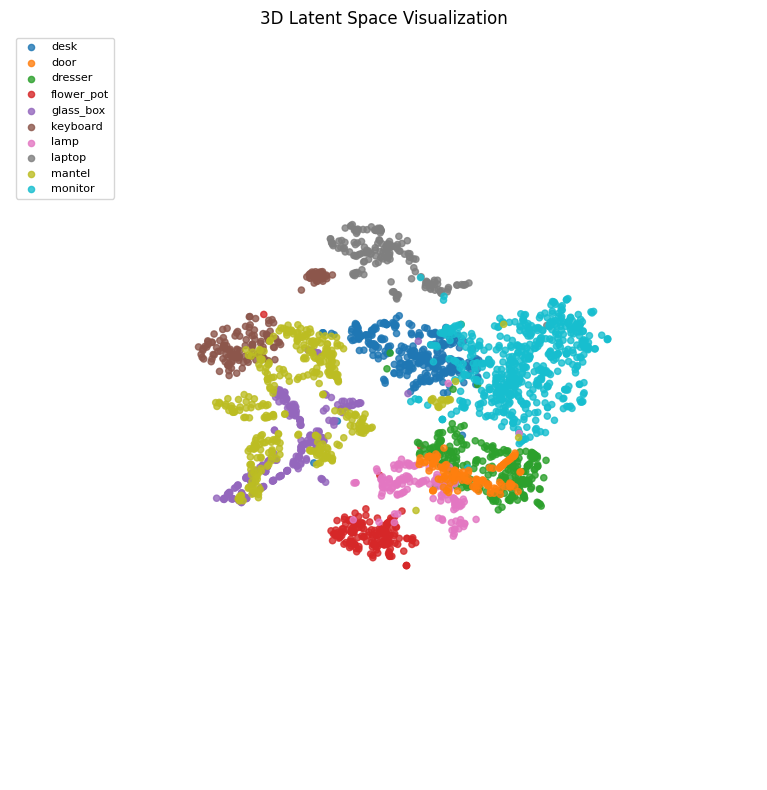

In [21]:
coords_3d = TSNE(n_components=3, init='pca', learning_rate='auto', random_state=42).fit_transform(all_mus)

def plot_3d_latent_space(ax, coords, labels, classes, elev, azim, title=''):
    colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
    for idx, (name, color) in enumerate(zip(classes, colors)):
        mask = (labels == idx)
        ax.scatter(coords[mask, 0], coords[mask, 1], coords[mask, 2], s=20, color=color, alpha=0.8, label=name)
    ax.set_title(title, fontsize=12)
    ax.view_init(elev=elev, azim=azim)
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.grid(False)
    ax.set_axis_off()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
plot_3d_latent_space(ax, coords_3d, all_labels, classes, elev=20, azim=60, title='3D Latent Space Visualization')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'latent_space_3d.png'), dpi=200)
plt.show()

# Create frames for GIF
frames = []
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i, azim in enumerate(range(0, 360, 5)): # Rotate 360 degrees in 5-degree steps
    ax.cla()
    plot_3d_latent_space(ax, coords_3d, all_labels, classes, elev=20, azim=azim, title='3D Latent Space Visualization')

    # Save frame to buffer
    plt.savefig('temp_frame.png', dpi=100) # Save temporary image
    frames.append(imageio.imread('temp_frame.png'))

plt.close(fig)
gif_path = os.path.join(OUT_DIR, 'latent_space_3d.gif')
imageio.mimsave(gif_path, frames, fps=10)

if os.path.exists('temp_frame.png'):
    os.remove('temp_frame.png')

## 10. Reconstrucción GT vs Pred (test set)

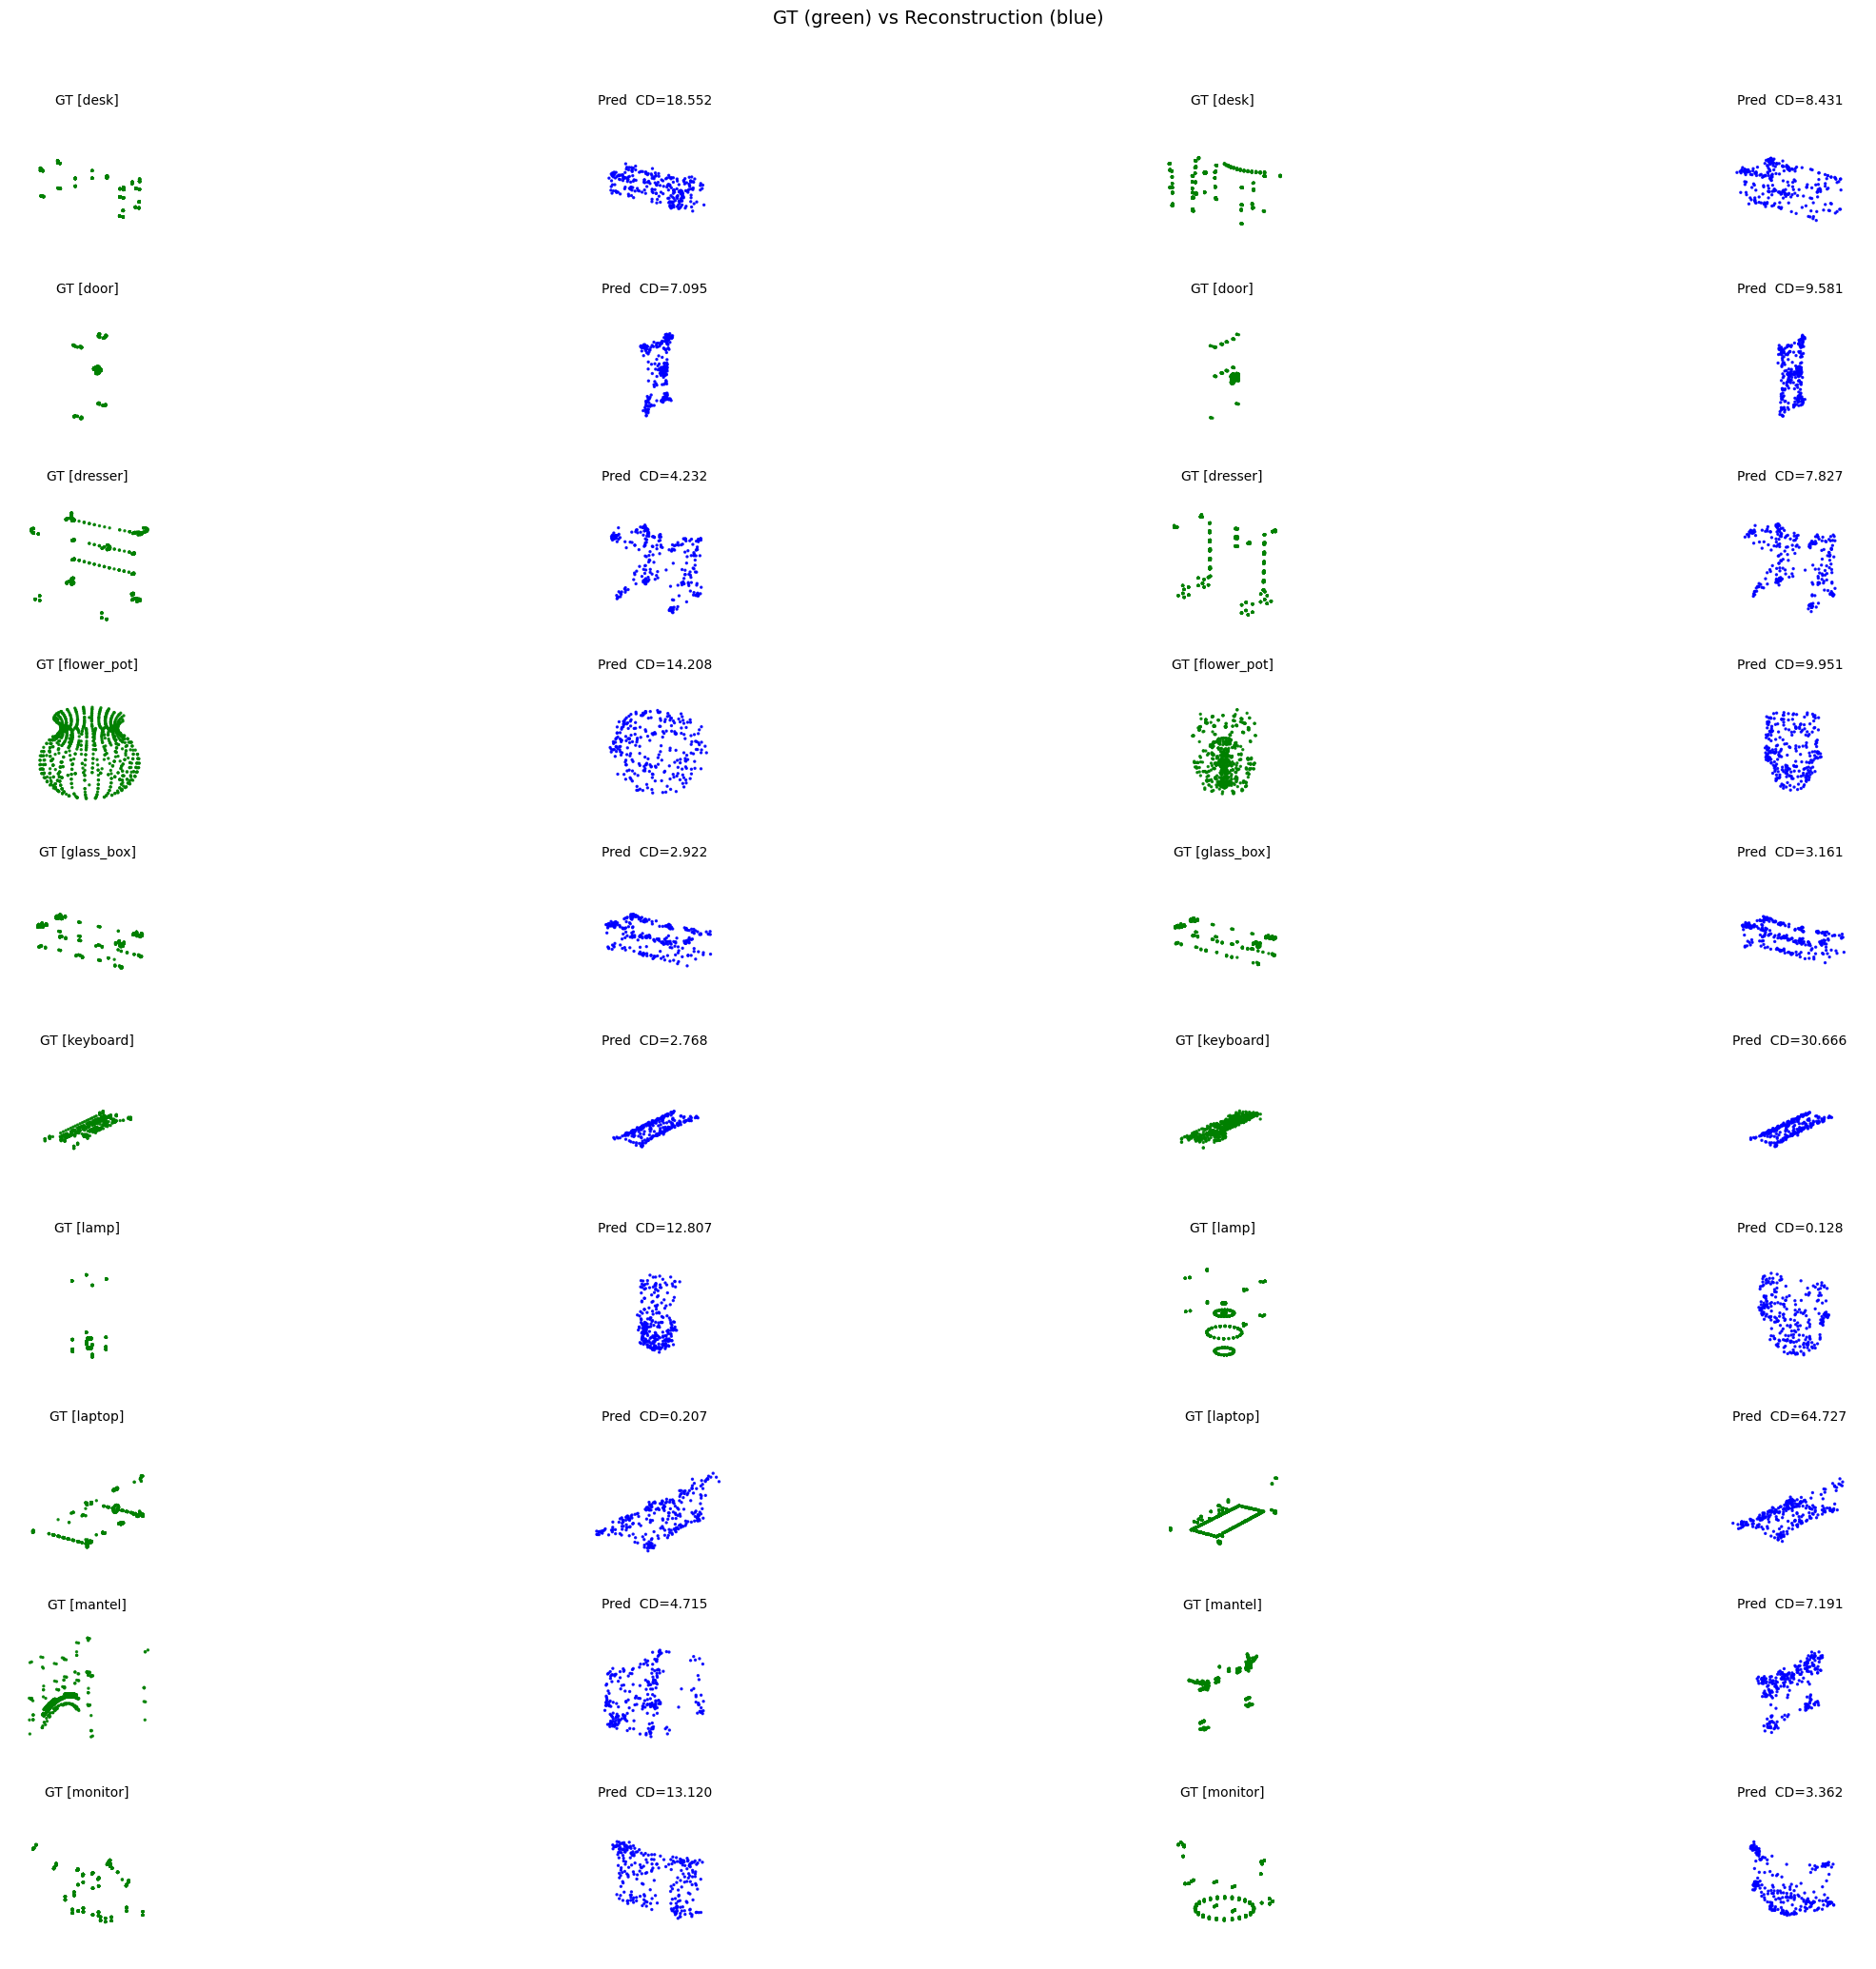

In [22]:
# Muestra N ejemplos por clase
N_PER_CLASS = 2

n_cls = len(classes)
fig = plt.figure(figsize=(6 * N_PER_CLASS * 2, 4 * n_cls))
plot_idx = 1

for cls_name in classes:
    idxs = class_indices[cls_name][:N_PER_CLASS]
    for g in idxs:
        mu     = encode_idx(te_bps, g)
        r_bps  = decode_mu(mu)[0]
        pred_w = denorm(bps2pts(basis, r_bps), te_c[g], te_s[g])
        gt_w   = denorm(te_pts[g],             te_c[g], te_s[g])
        cd     = chamfer(pred_w, gt_w)

        ax = fig.add_subplot(n_cls * N_PER_CLASS, 4, plot_idx,   projection='3d')
        plot_pc(ax, gt_w,   'green', f'GT [{cls_name}]')
        ax = fig.add_subplot(n_cls * N_PER_CLASS, 4, plot_idx+1, projection='3d')
        plot_pc(ax, pred_w, 'blue', f'Pred  CD={cd:.3f}')
        plot_idx += 2

plt.suptitle('GT (green) vs Reconstruction (blue)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'reconstruction_grid.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11. Interpolación intra-clase

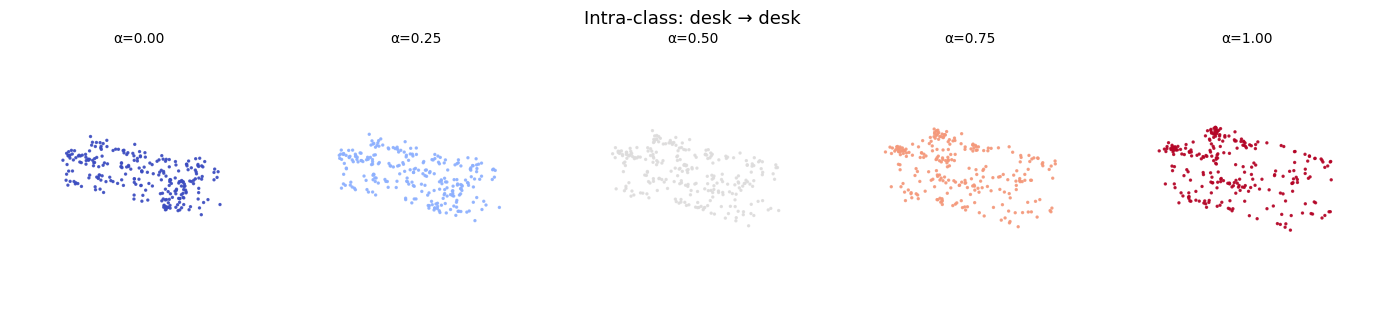

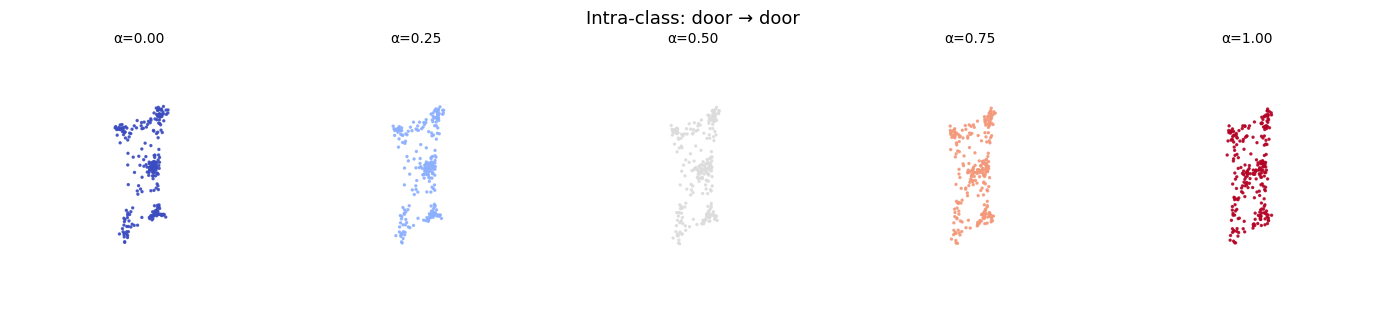

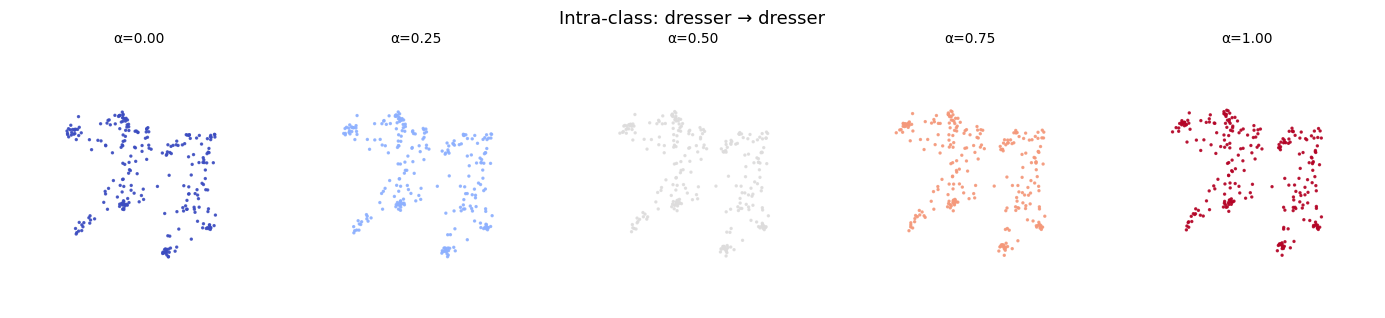

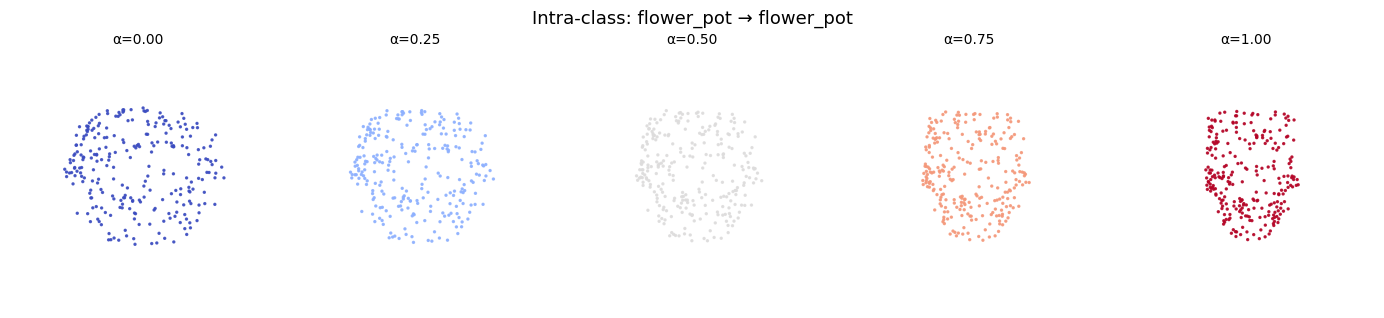

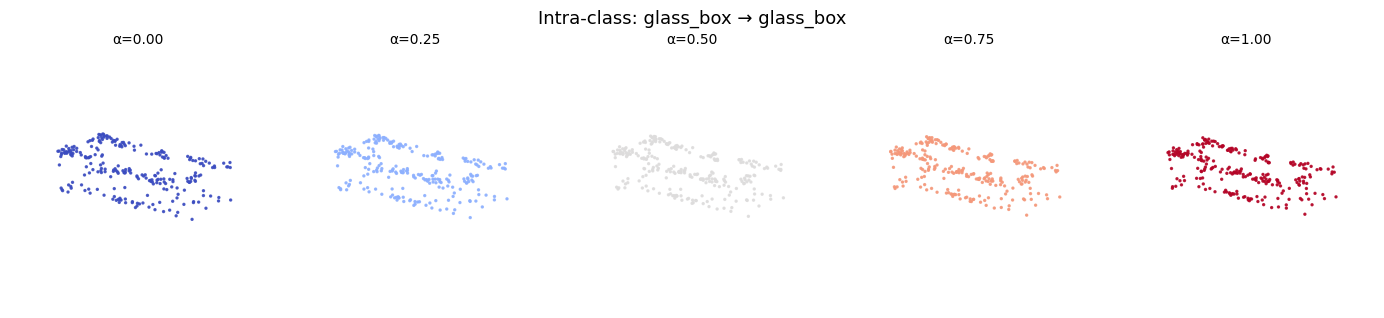

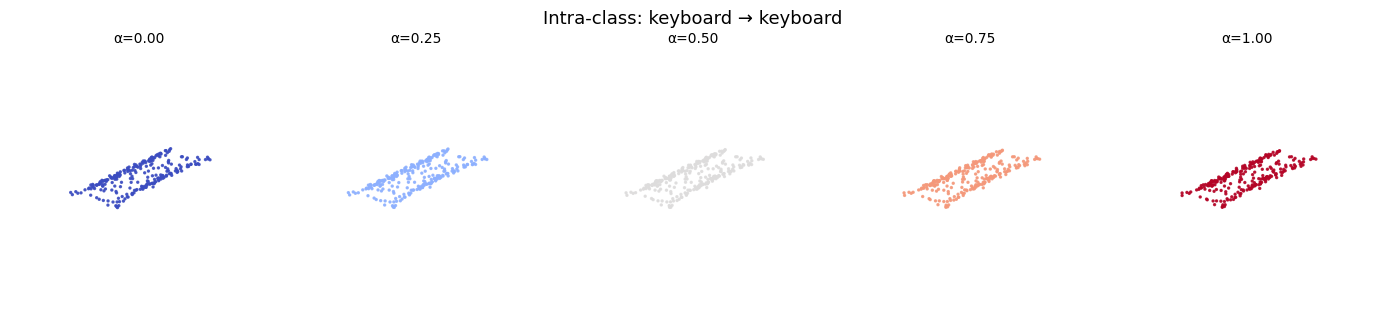

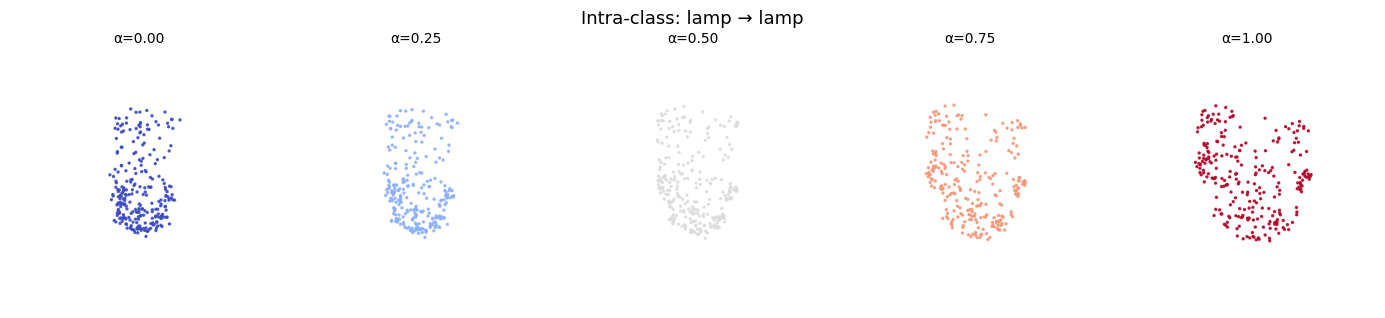

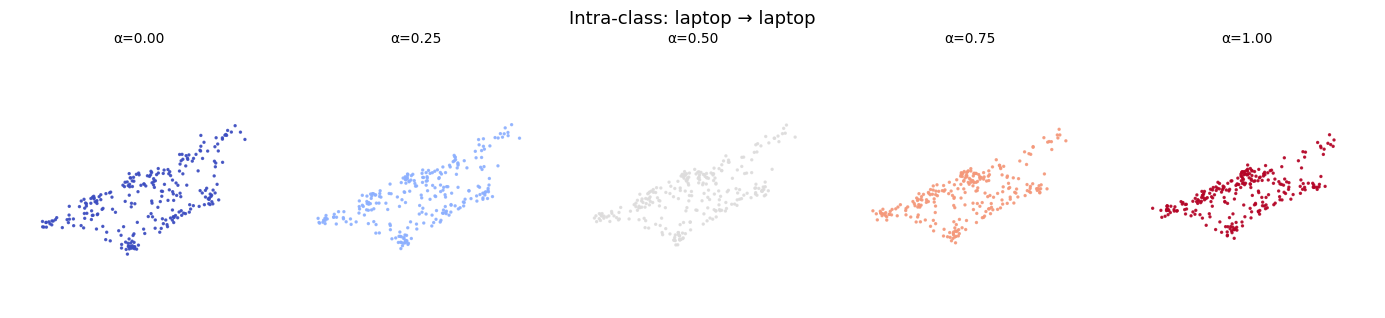

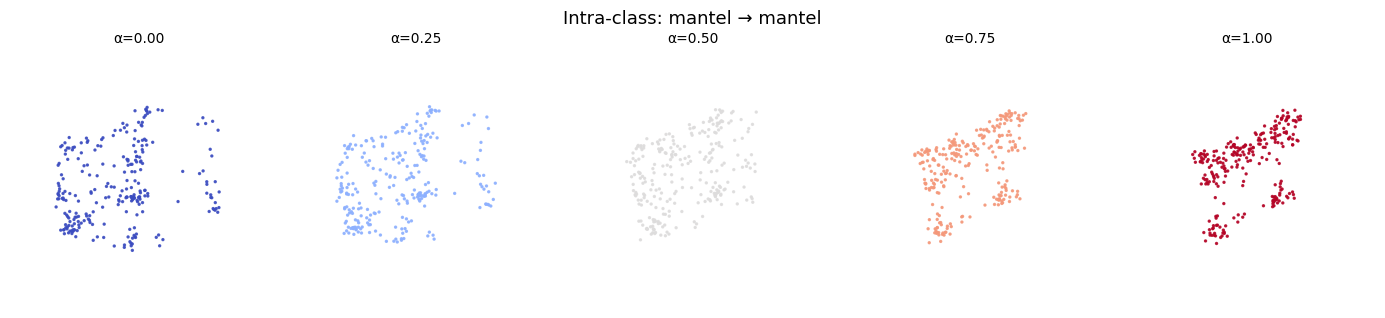

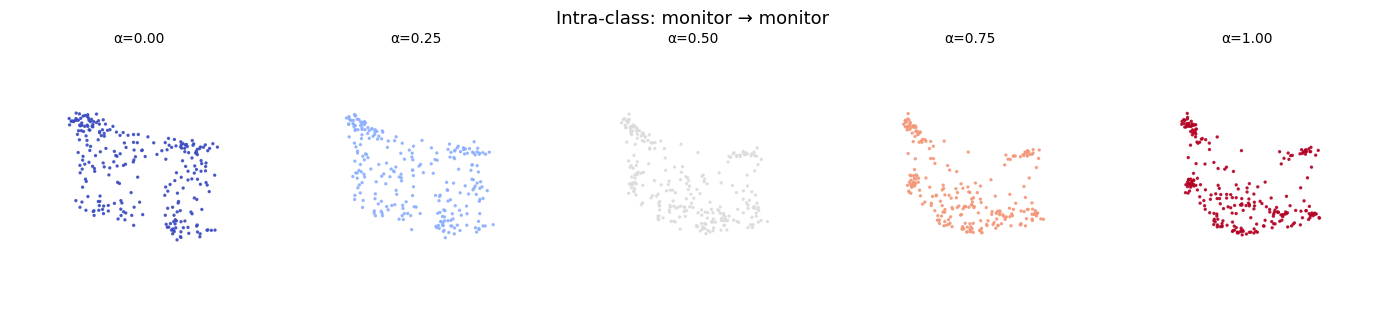

In [23]:
N_INTERP    = 5
def interpolate_and_plot(idx_a, idx_b, label_a, label_b,
                         bps_std, pts_norm, centroids, scales,
                         n_steps=N_INTERP, title='Interpolation'):
    mu_a = encode_idx(bps_std, idx_a)
    mu_b = encode_idx(bps_std, idx_b)

    alphas = torch.linspace(0, 1, n_steps, device=device).view(-1, 1)
    z_seq  = (1 - alphas) * mu_a + alphas * mu_b
    bps_seq = decode_mu(z_seq)   # (n_steps, n_bps*3)

    cols = n_steps
    fig  = plt.figure(figsize=(cols * 2.8, 3.2))

    for i in range(n_steps):
        ref   = idx_a if i < n_steps // 2 else idx_b
        pred  = denorm(bps2pts(basis, bps_seq[i]), centroids[ref], scales[ref])
        color = plt.cm.coolwarm(i / (n_steps - 1))

        ax = fig.add_subplot(1, cols, i + 1, projection='3d')
        plot_pc(ax, pred, [color], title=f'α={float(alphas[i]):.2f}')

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    fname = title.lower().replace(' ', '_').replace('→','to') + '.png'
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=130, bbox_inches='tight')
    plt.show()


# Intra-clase: dos muestras de la misma clase
for cls_name in classes:
    idxs = class_indices[cls_name]
    if len(idxs) < 2:
        continue
    idx_a, idx_b = int(idxs[0]), int(idxs[1])
    interpolate_and_plot(
        idx_a, idx_b,
        cls_name, cls_name,
        te_bps, te_pts, te_c, te_s,
        title=f'Intra-class: {cls_name} → {cls_name}',
    )

## 12. Interpolación inter-clase

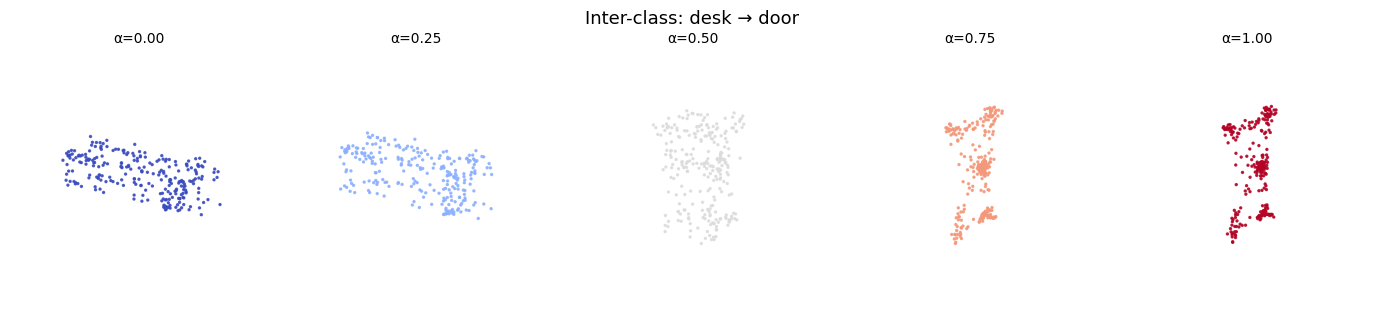

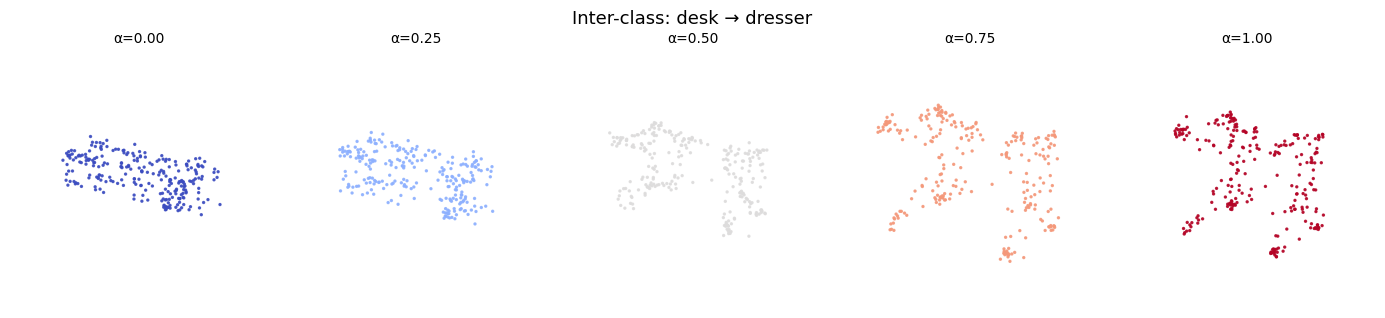

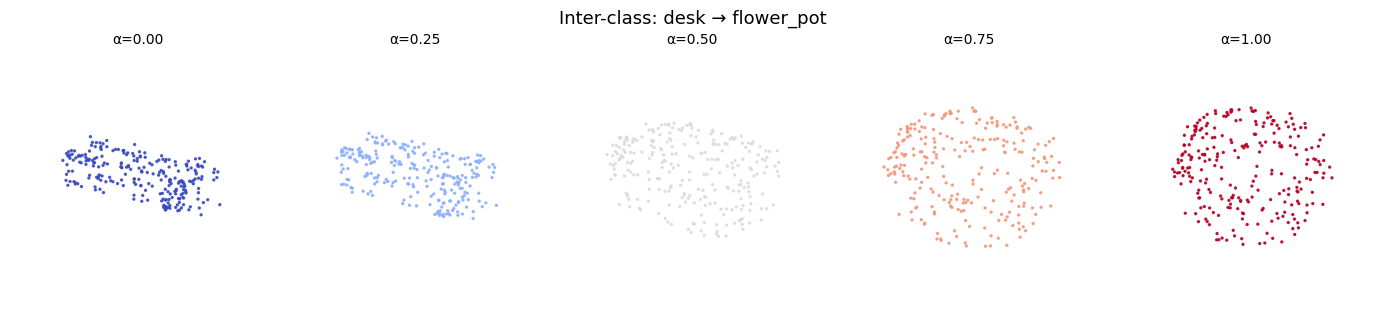

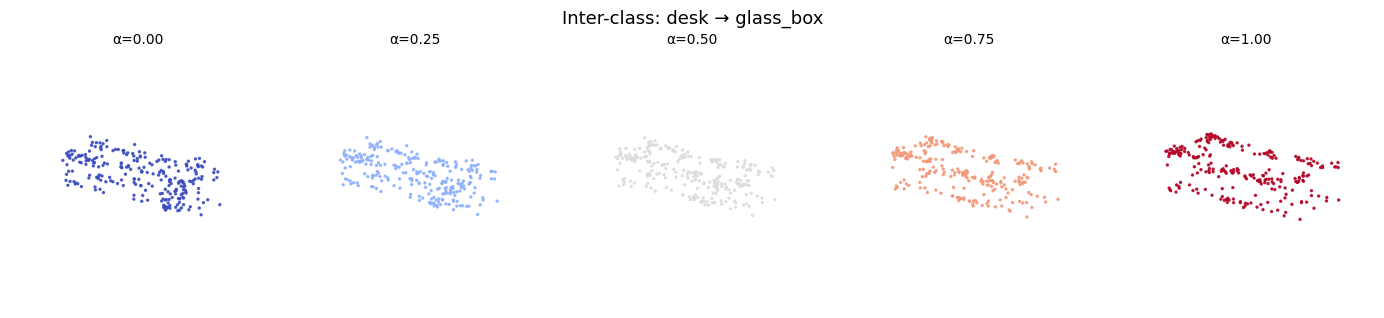

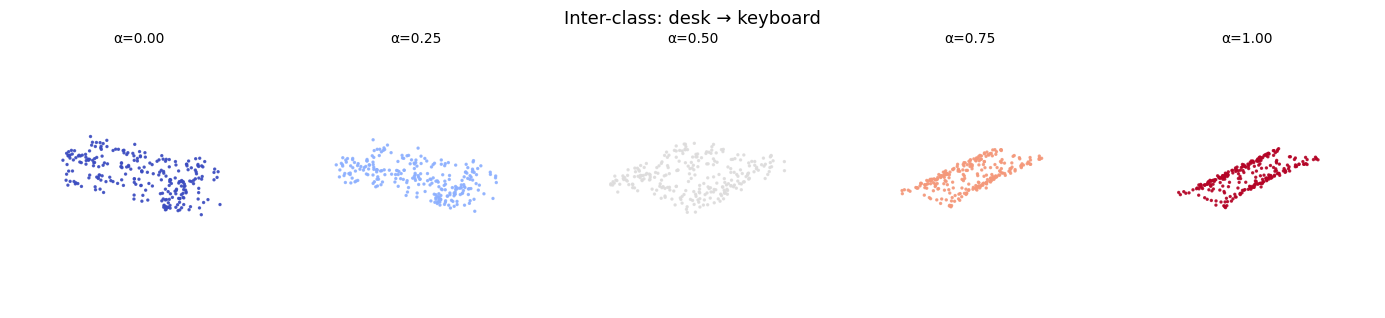

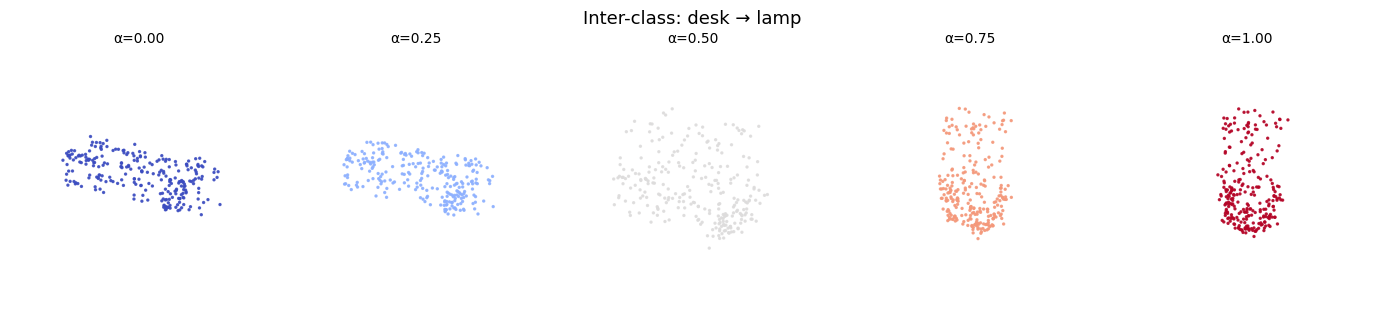

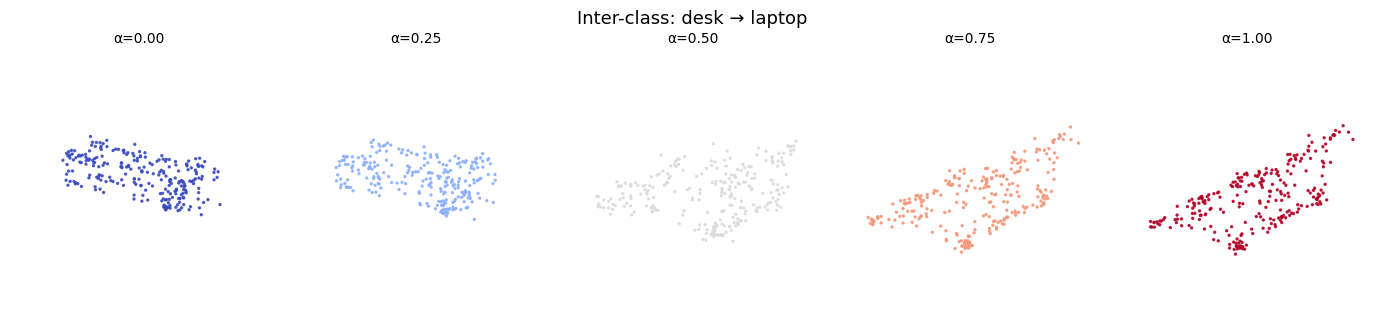

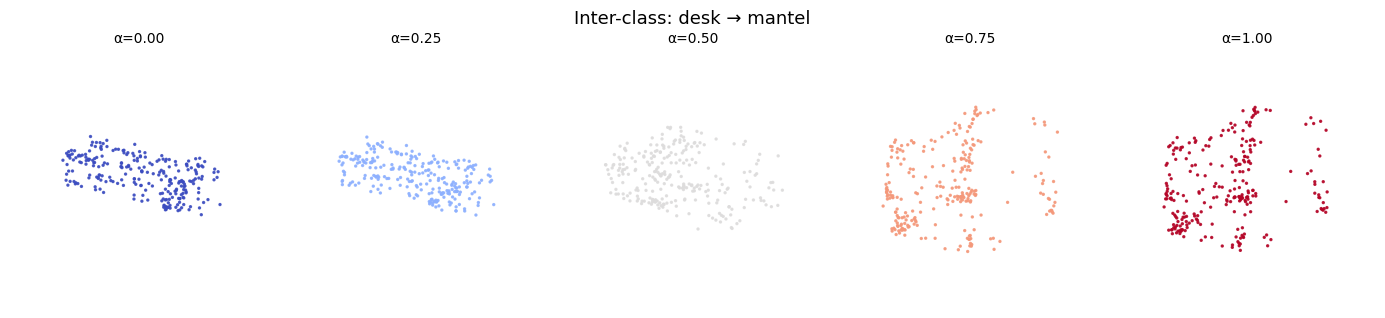

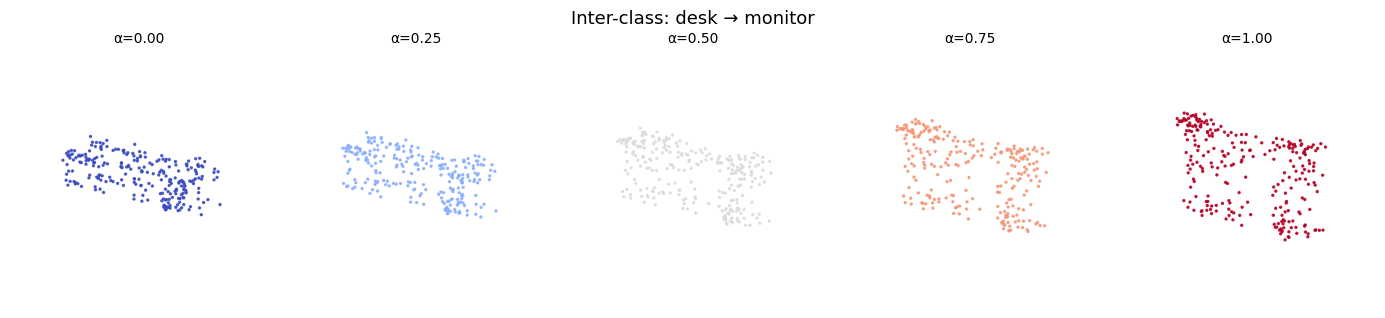

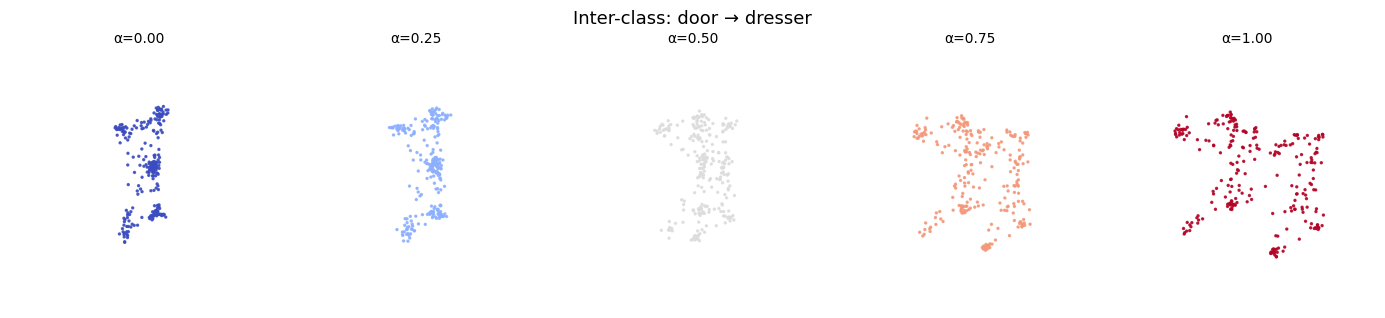

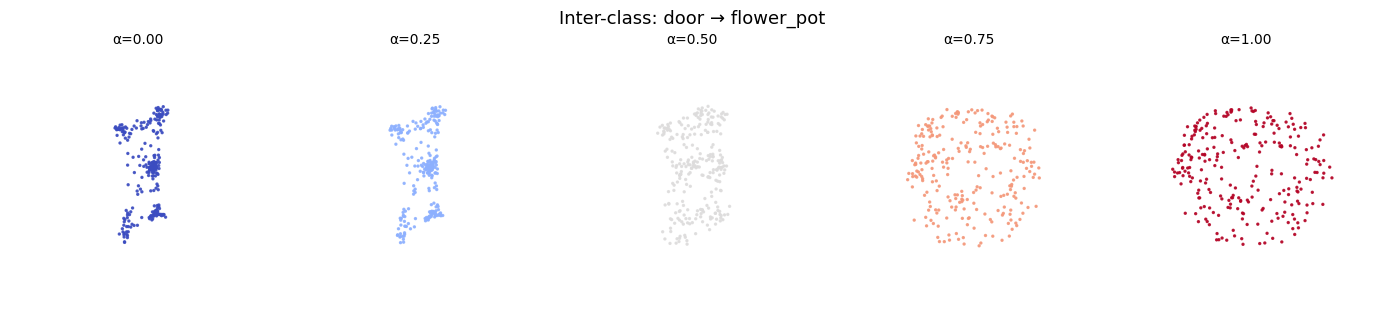

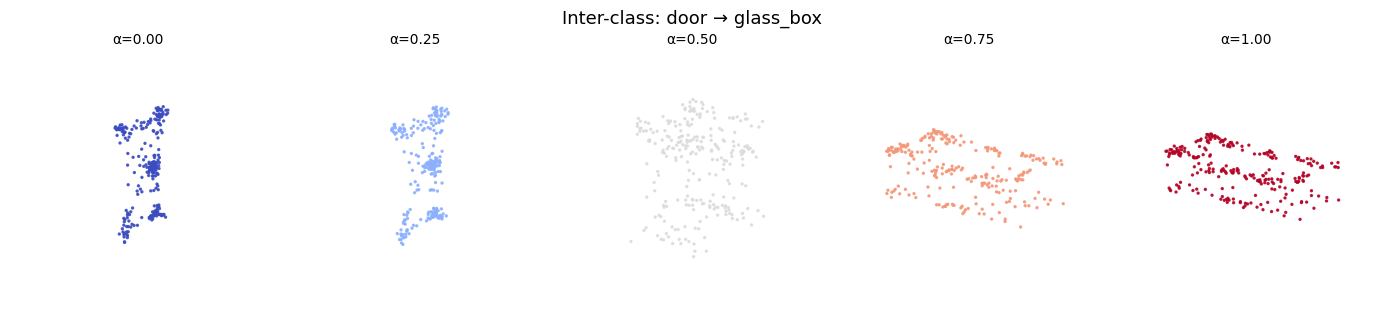

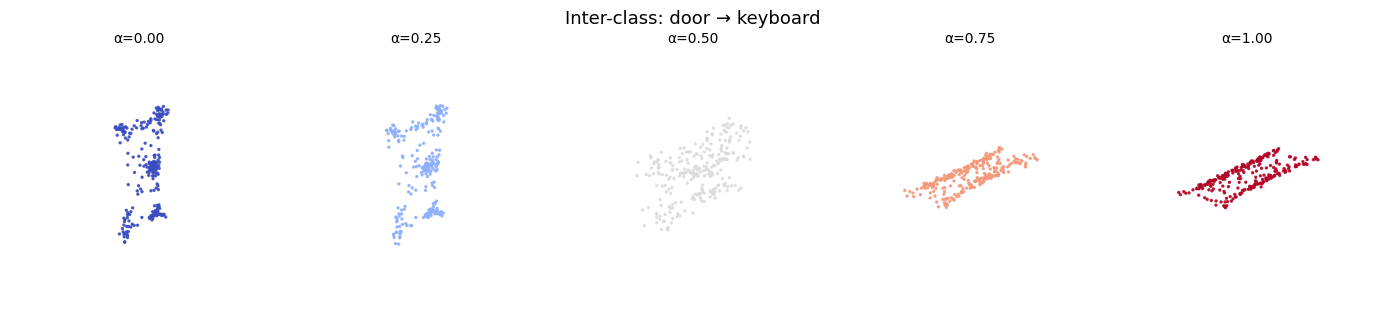

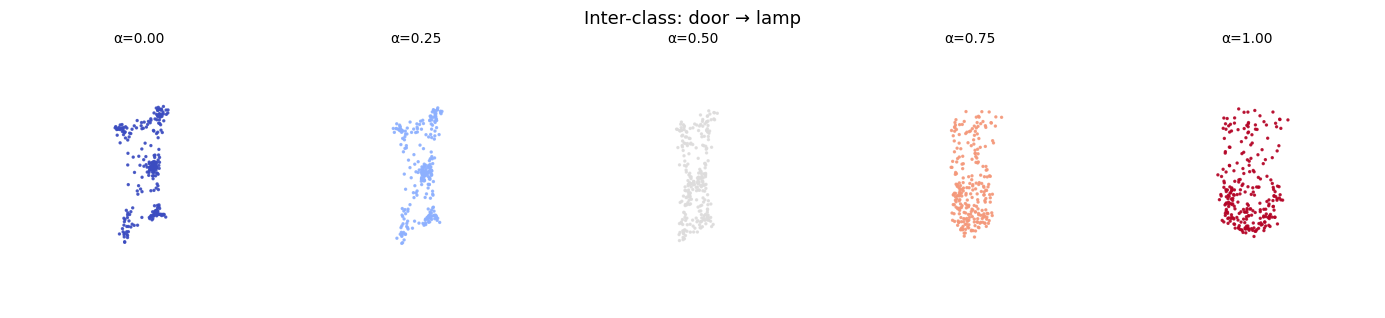

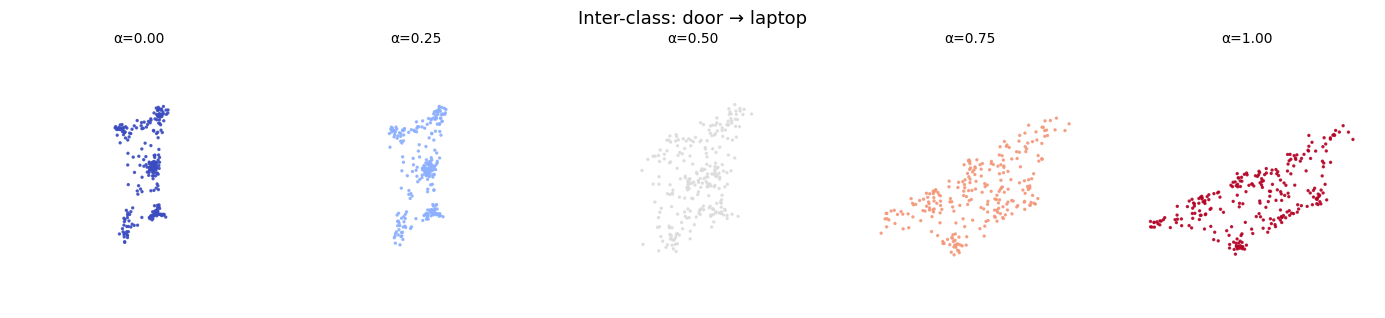

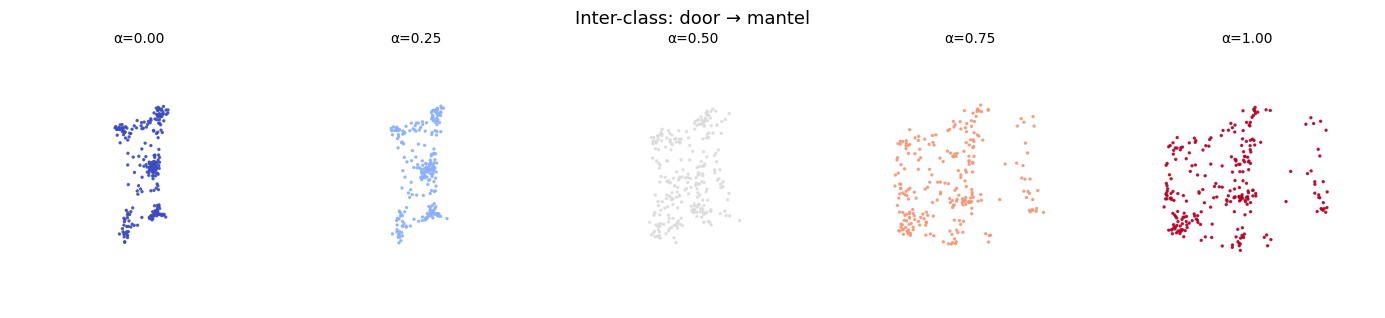

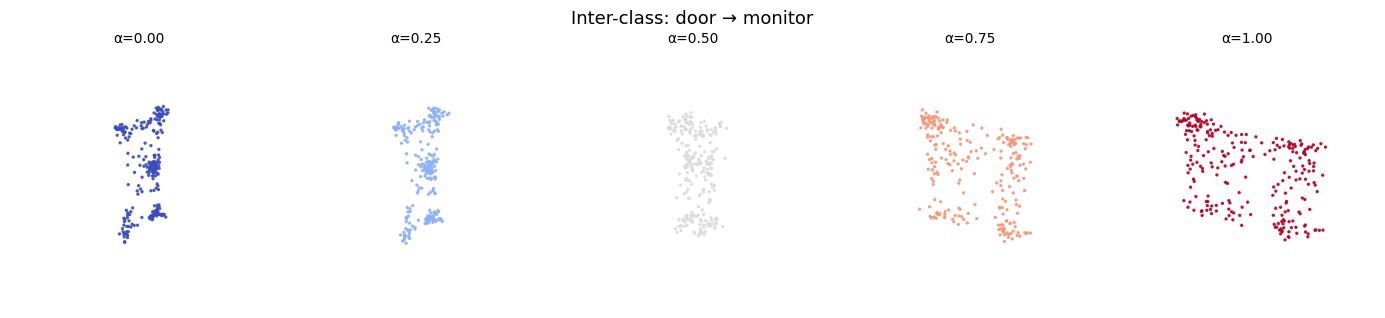

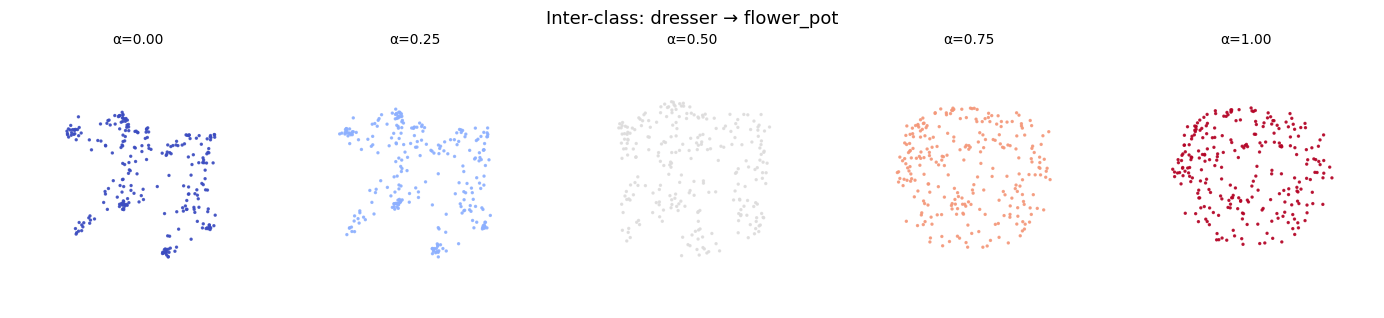

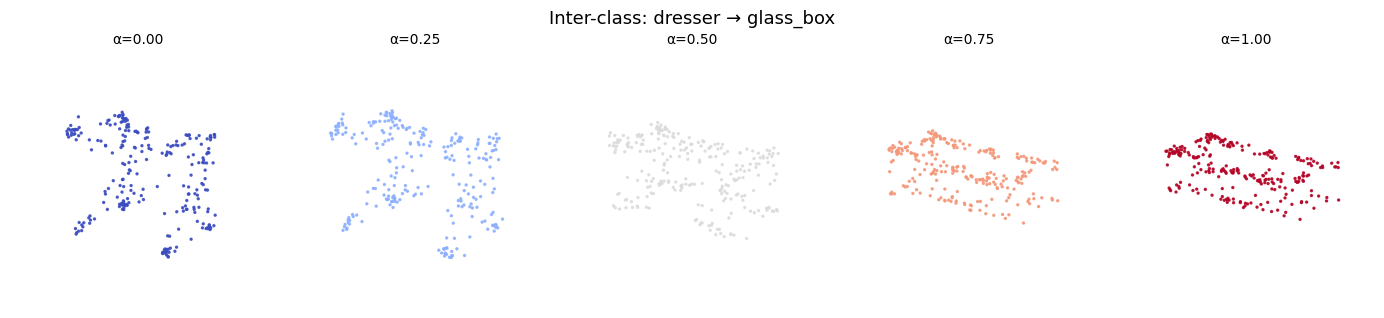

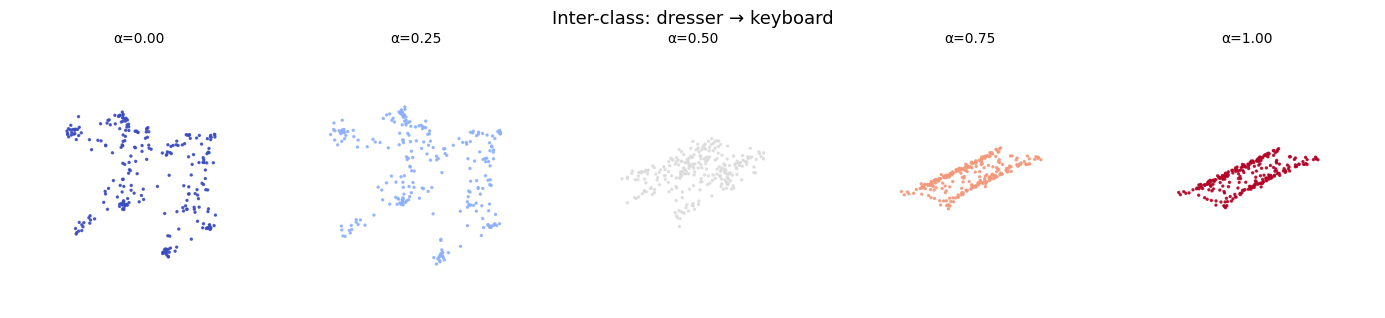

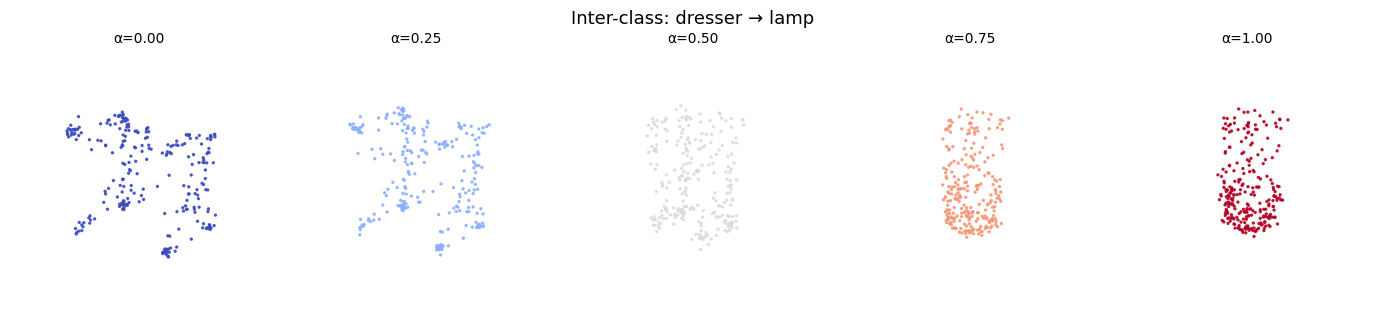

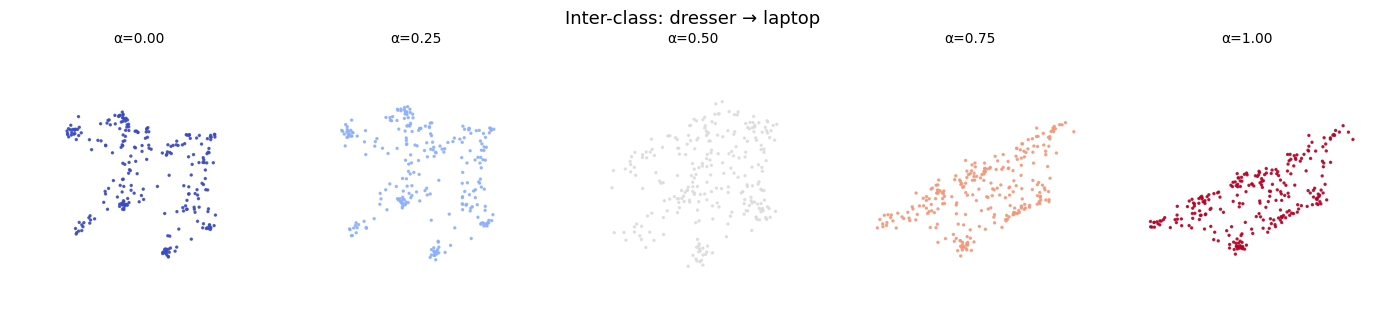

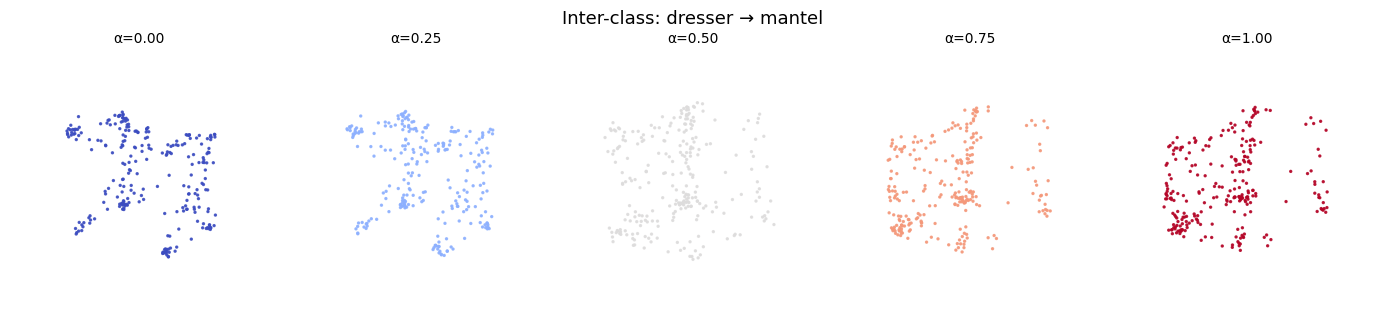

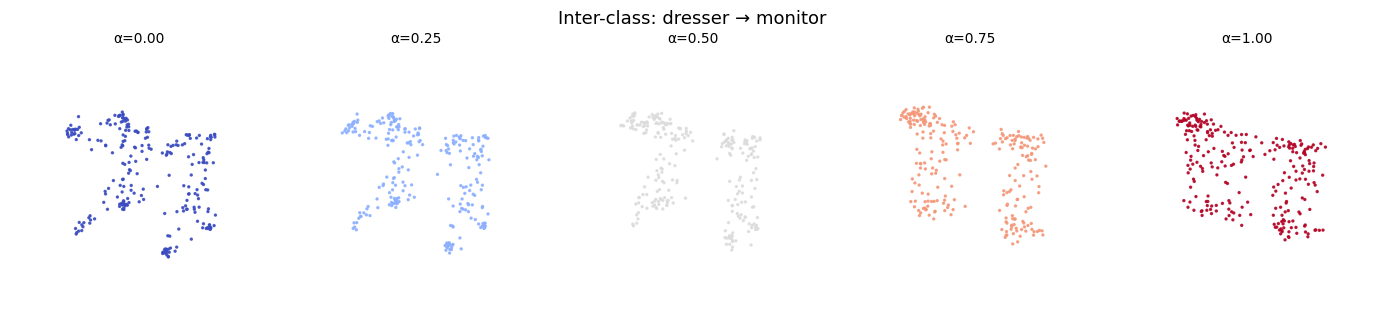

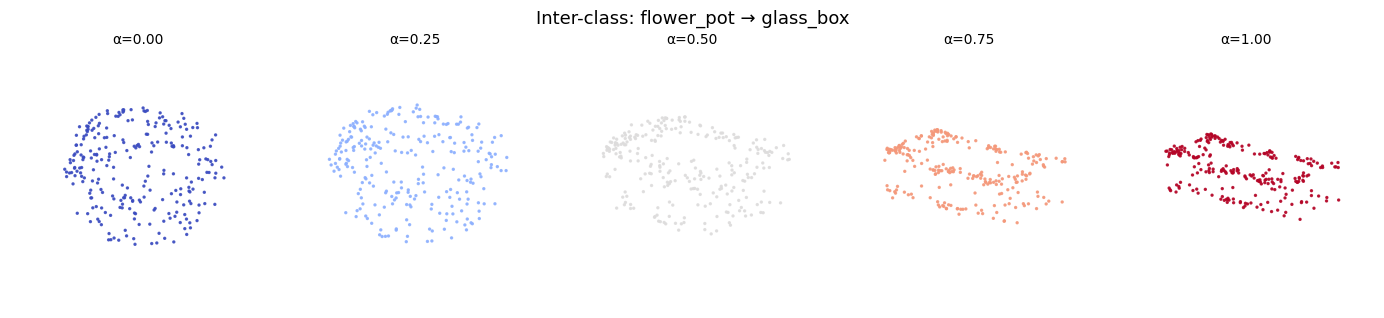

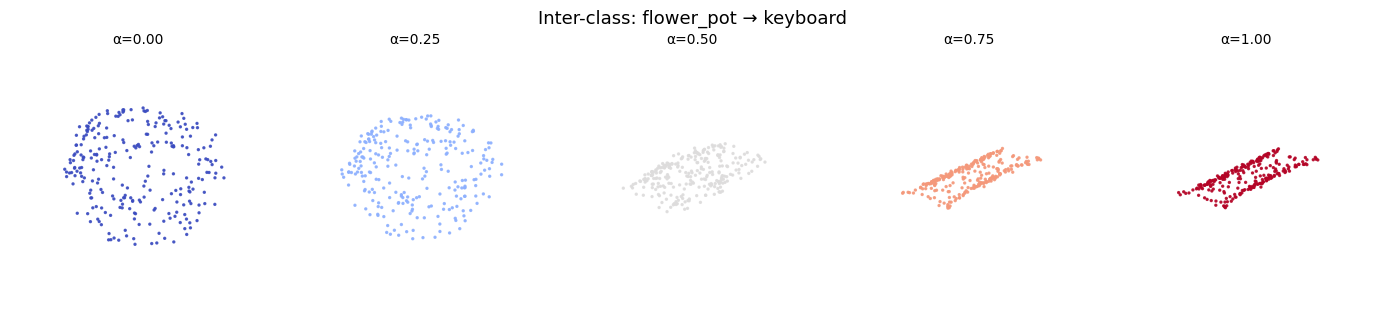

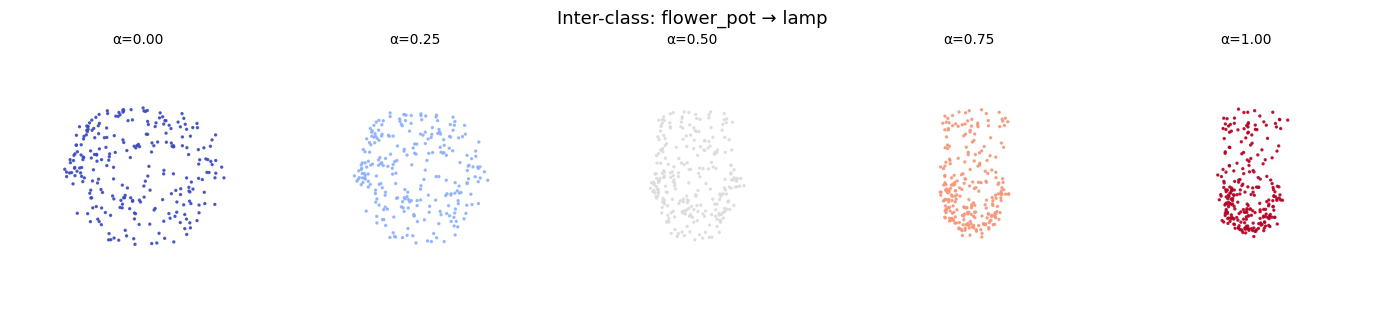

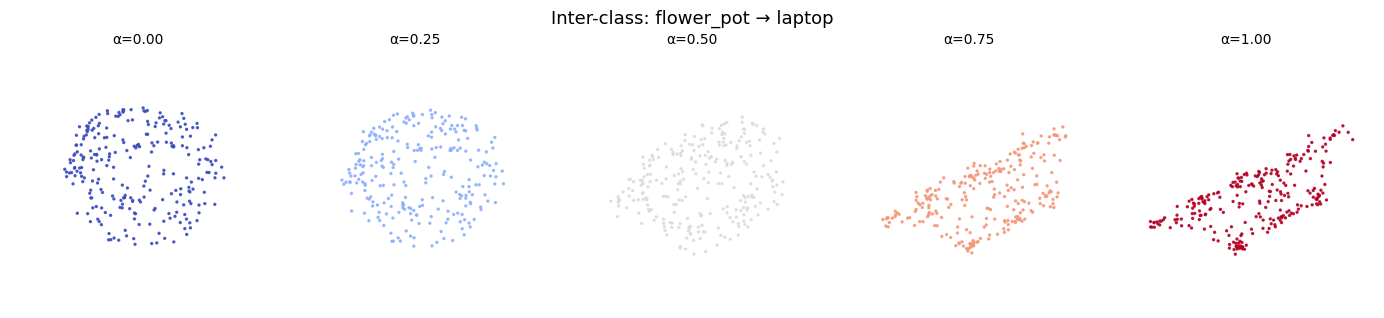

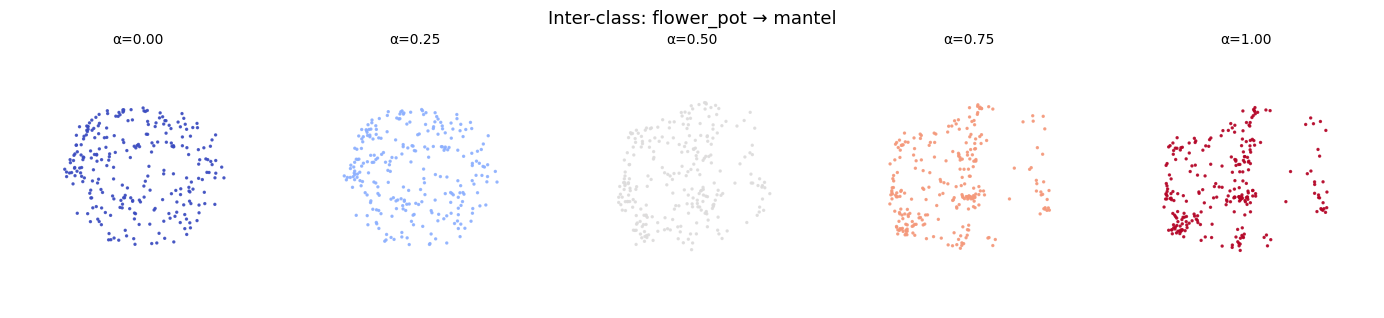

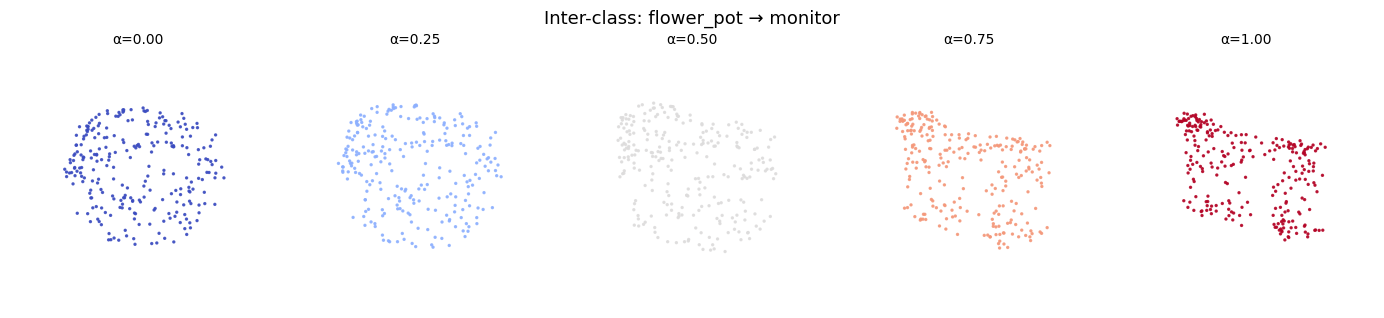

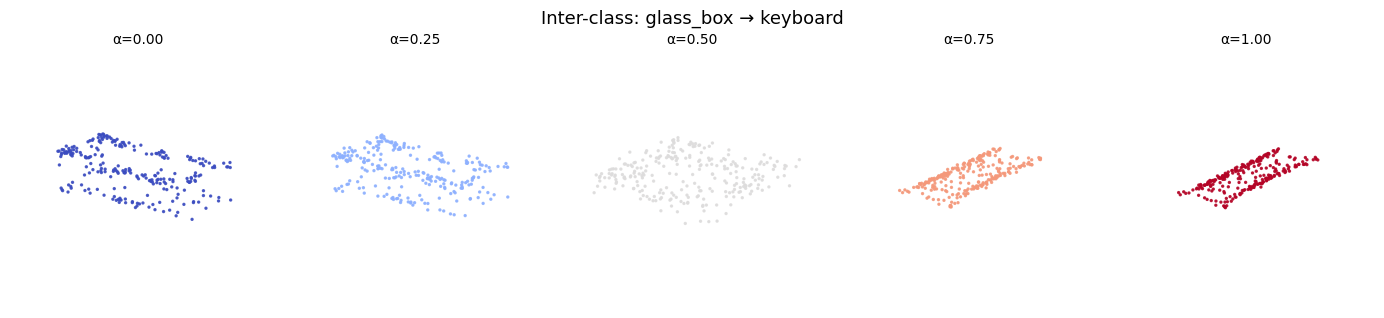

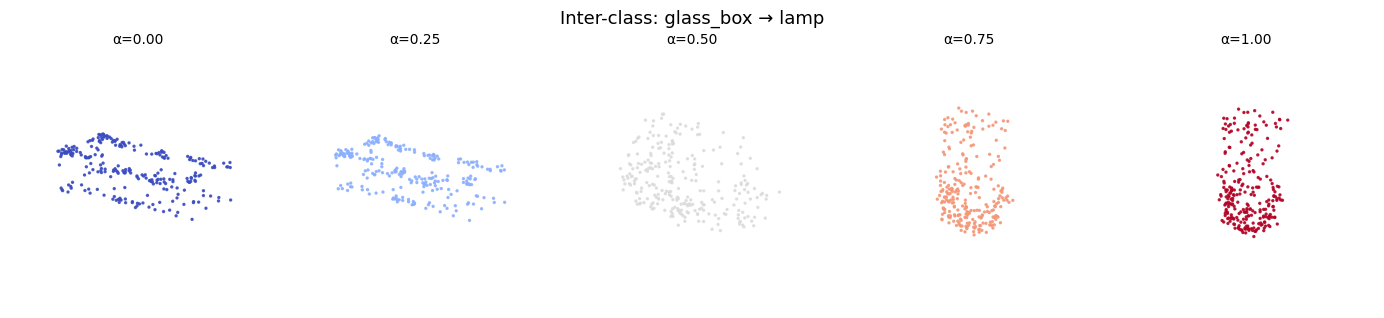

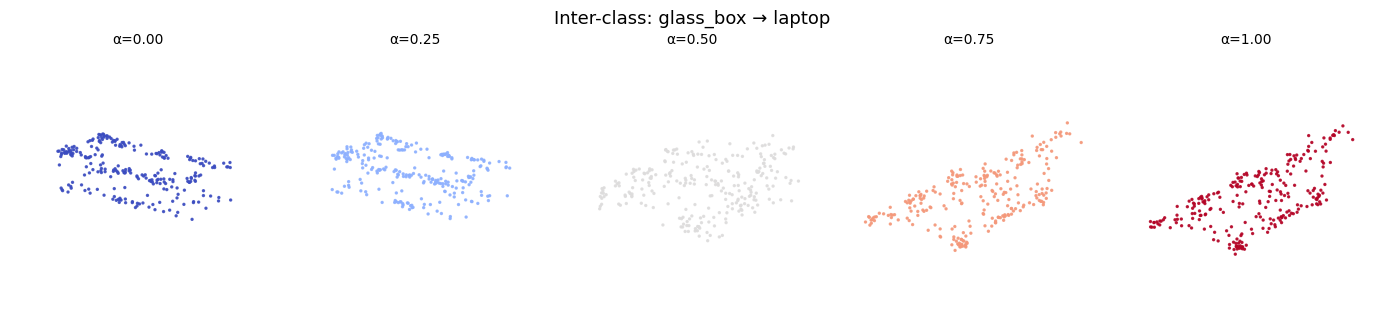

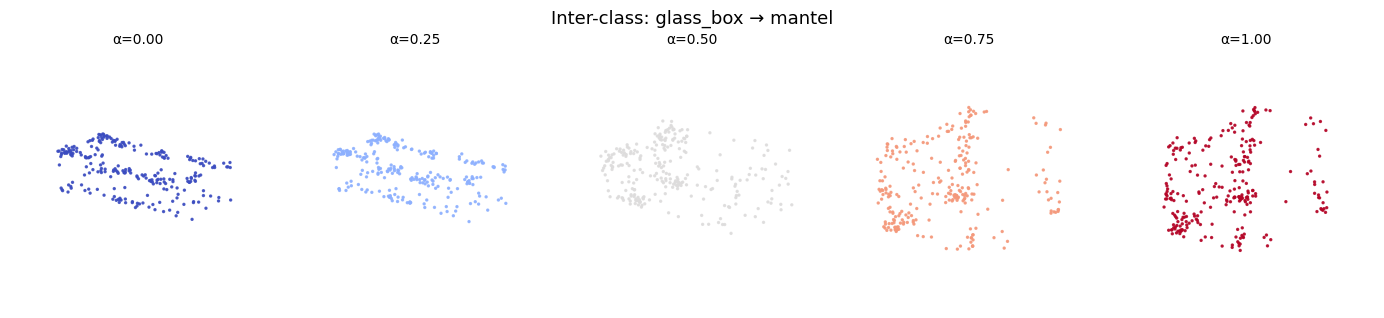

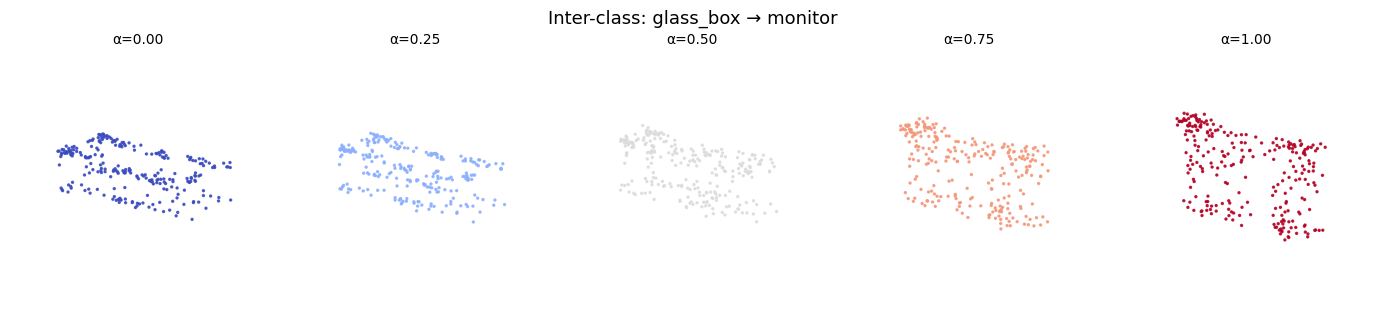

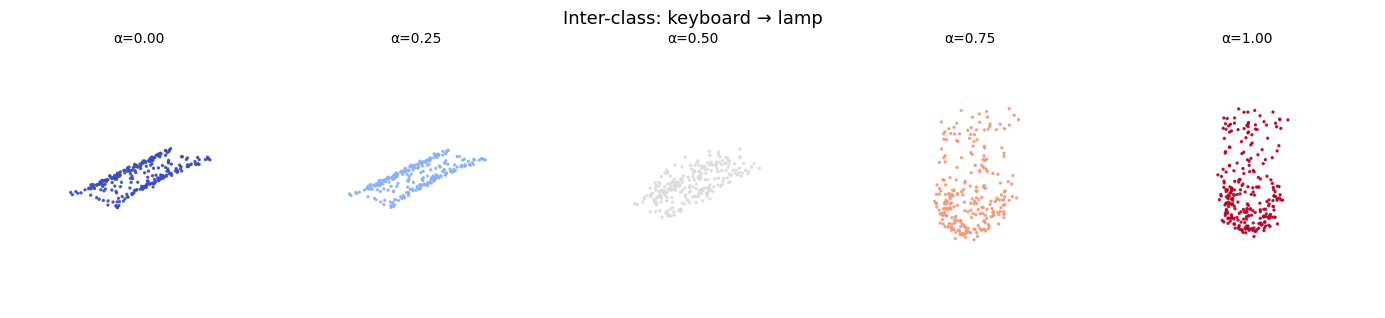

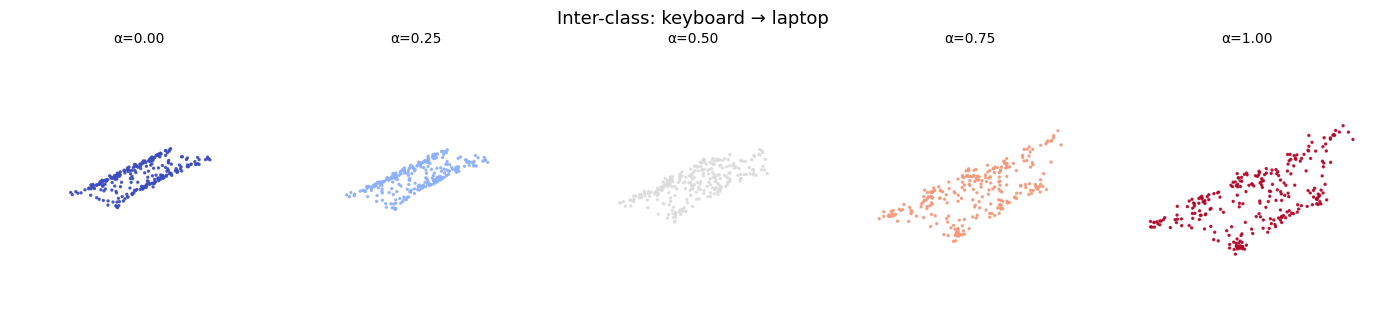

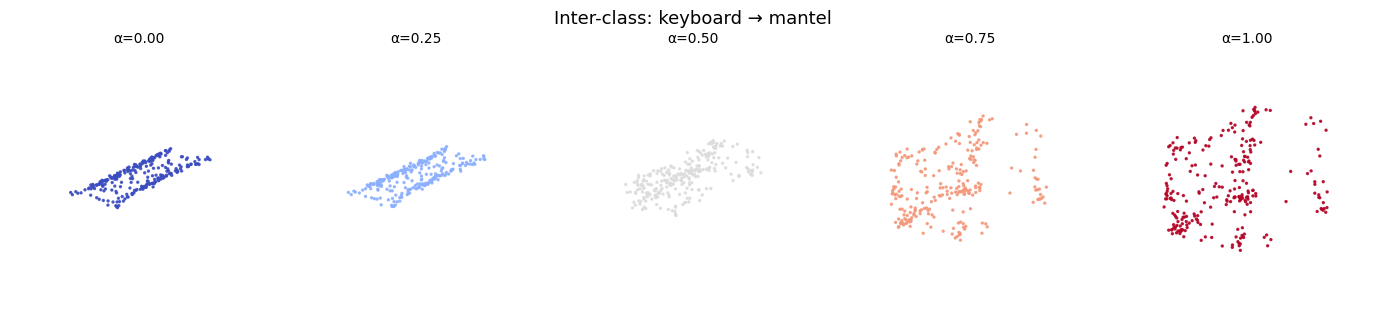

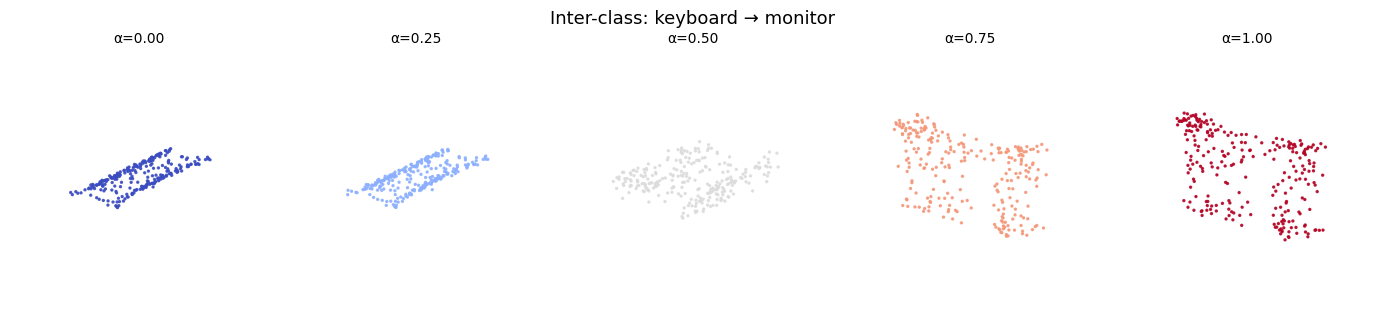

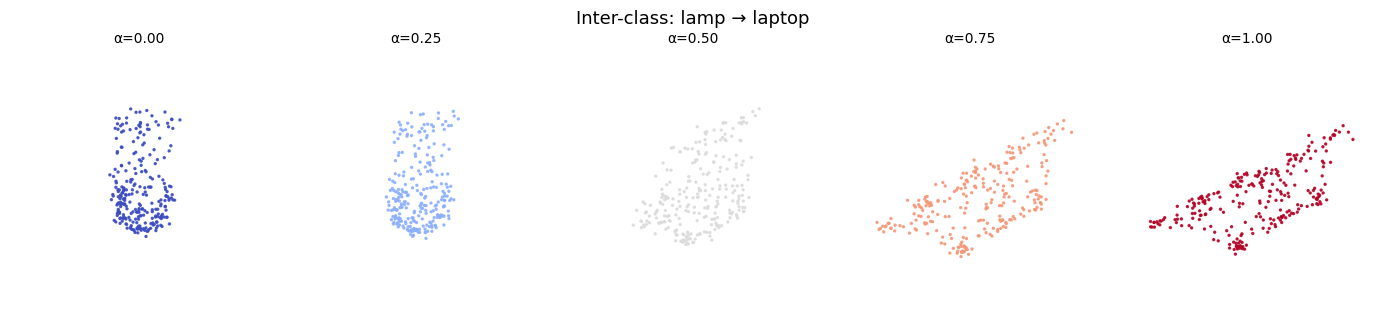

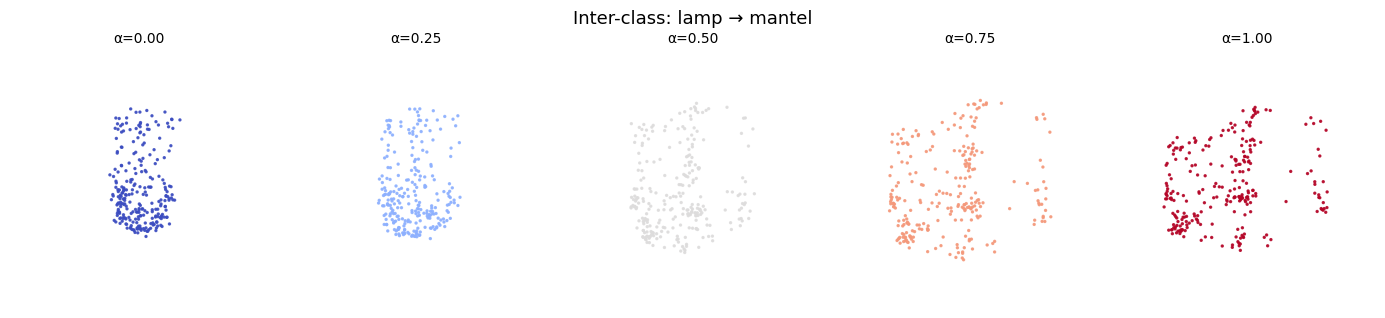

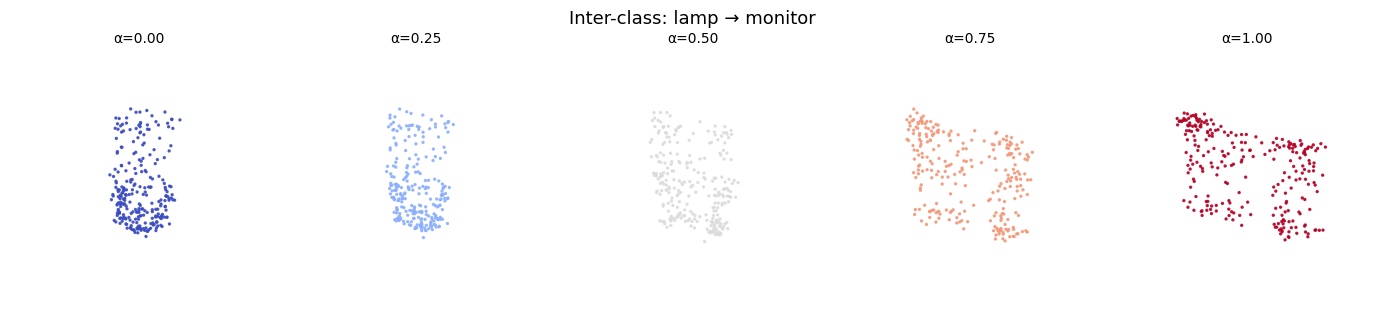

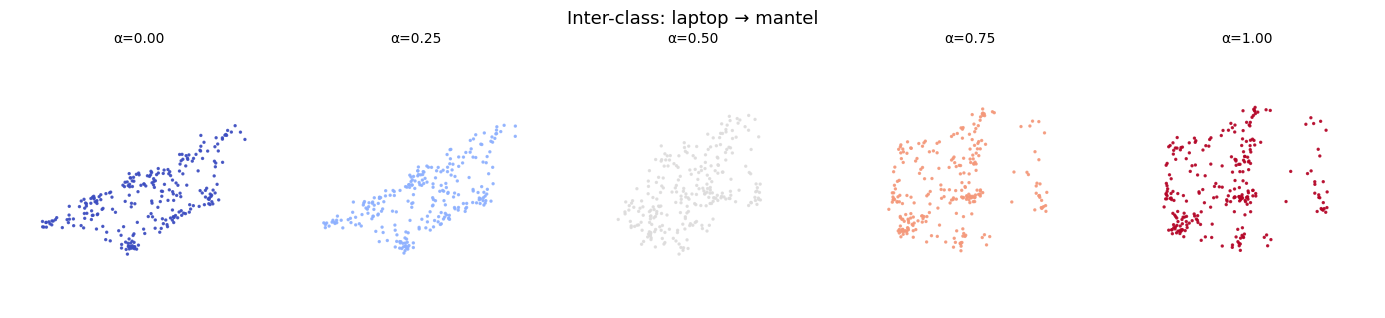

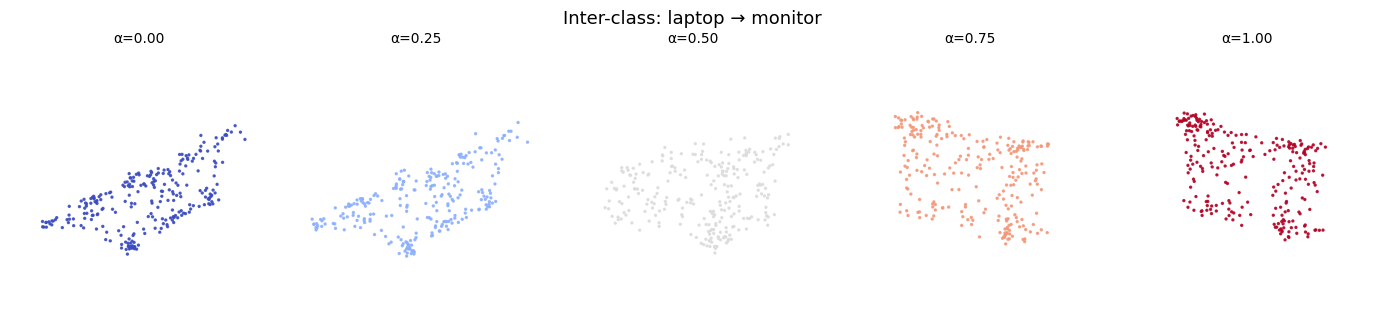

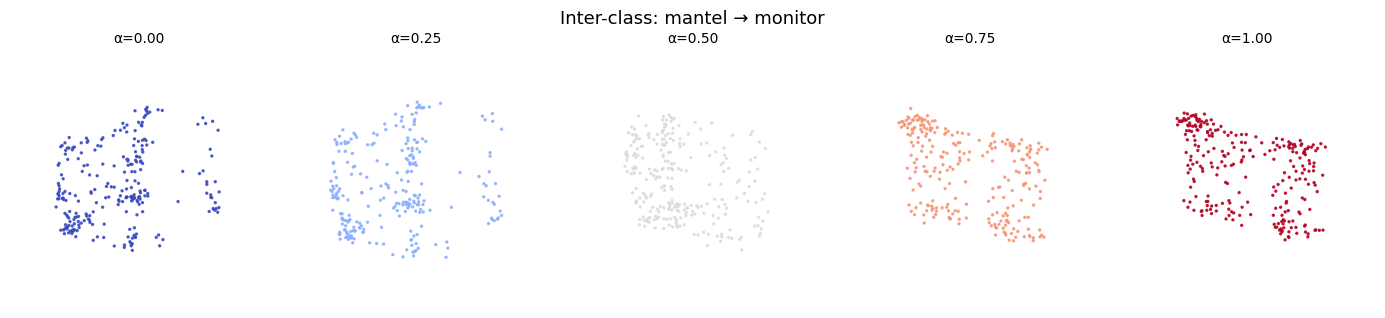

In [24]:
# Todos los pares de clases distintas
for cls_a, cls_b in itertools.combinations(classes, 2):
    idx_a = int(class_indices[cls_a][0])
    idx_b = int(class_indices[cls_b][0])
    interpolate_and_plot(
        idx_a, idx_b,
        cls_a, cls_b,
        te_bps, te_pts, te_c, te_s,
        title=f'Inter-class: {cls_a} → {cls_b}',
    )